In [1]:
from pathlib import Path
import yaml
import pandas as pd
from tqdm.notebook import tqdm
import multiprocessing as mp
from typing import Tuple, List, Dict, Any
from functools import partial

In [2]:
def resolve_base_output_dir() -> Path:
    """Resolve CPM dataset root from common local project paths."""
    candidates = [
        Path("CPM"),
        Path("../CPM"),
        Path("dataset/CPM"),
        Path("../dataset/CPM"),
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError("Could not find CPM dataset folder. Checked: CPM, ../CPM, dataset/CPM, ../dataset/CPM")

BASE_OUTPUT_DIR = resolve_base_output_dir()
print(f"BASE_OUTPUT_DIR: {BASE_OUTPUT_DIR}")

BASE_OUTPUT_DIR: /Users/dhianeifar/PycharmProjects/GenCPM/CPM


# Load Dataset

In [3]:
# CRITICAL: Set start method for macOS/Jupyter compatibility
try:
    mp.set_start_method('fork', force=True)
except RuntimeError:
    pass  # Already set

In [4]:
def iter_cpm_files(root: Path):
    """
    Yield (sim_name, cpm_path) for every CPM YAML under all town/scenario folders.
    sim_name is the path relative to root, e.g. Town01/2025_12_22_00_29_15.
    """
    if not root.exists():
        raise FileNotFoundError(f"CPM root does not exist: {root}")

    for f in root.rglob("*.yaml"):
        if not f.is_file():
            continue
        # Skip per-run metadata files (simulation_config.yaml or simulation_config_rXXX.yaml).
        if f.name.startswith("simulation_config"):
            continue

        rel_parent = f.parent.relative_to(root)
        sim_name = rel_parent.as_posix() if rel_parent.parts else root.name
        yield sim_name, f

In [5]:
def load_cpm_yaml(path: Path) -> dict:
    """Load a single YAML file."""
    with path.open("r") as f:
        return yaml.load(f, Loader=yaml.UnsafeLoader)

In [6]:
def process_single_cpm(sim_name: str, cpm_path: Path) -> Tuple[Dict, List[Dict]]:
    """
    Process a single CPM file and return (cpm_row, vehicle_rows).
    This function must be picklable for multiprocessing.
    """
    try:
        cpm = load_cpm_yaml(cpm_path)
        
        attacks = cpm.get("attacks", []) or []
        is_malicious = cpm.get("cpm_type") == "malicious"
        attack_types = sorted({a.get("attack_type") for a in attacks if a is not None})
        attack_types_str = ",".join(attack_types) if attack_types else None
        num_attacks = len(attacks)
        
        # map obj_id -> attack types / altered fields
        obj_attack_map = {}       # id -> [attack_type, ...]
        obj_fields_map = {}       # id -> [field, ...]
        
        for a in attacks:
            if not a:
                continue
            a_type = a.get("attack_type")
            altered_fields = a.get("altered_fields", []) or []
            for tid in a.get("target_ids", []) or []:
                try:
                    tid_int = int(tid)
                except (TypeError, ValueError):
                    continue
                obj_attack_map.setdefault(tid_int, []).append(a_type)
                obj_fields_map.setdefault(tid_int, []).extend(altered_fields)
        
        gp = cpm.get("global_position", {}) or {}
        detected_vehicles = cpm.get("detected_vehicles", []) or []
        detected_pedestrians = cpm.get("detected_pedestrians", []) or []
        
        # ---- CPM-level row ----
        cpm_row = {
            "sim_name": sim_name,
            "cpm_file": cpm_path.name,
            "vehicle_id": cpm.get("vehicle_id"),
            "timestamp": cpm.get("timestamp"),
            "vehicle_speed": cpm.get("vehicle_speed"),
            "cpm_type": cpm.get("cpm_type"),
            "is_malicious": is_malicious,
            "has_attacks": bool(attacks),
            "num_attacks": num_attacks,
            "attack_types": attack_types_str,
            "global_x": gp.get("x"),
            "global_y": gp.get("y"),
            "global_z": gp.get("z"),
            "num_detected_vehicles": len(detected_vehicles),
            "num_detected_pedestrians": len(detected_pedestrians),
        }
        
        # ---- object-level rows (all detected vehicles) ----
        veh_rows = []
        for rank, v in enumerate(detected_vehicles):
            loc = v.get("location", {}) or {}
            cen = v.get("center", {}) or {}
            ori = v.get("orientation", {}) or {}
            obj_id = v.get("id")
            
            try:
                obj_id_int = int(obj_id)
            except (TypeError, ValueError):
                obj_id_int = None
            
            obj_attack_types = []
            obj_altered_fields = []
            if obj_id_int is not None:
                obj_attack_types = obj_attack_map.get(obj_id_int, [])
                obj_altered_fields = obj_fields_map.get(obj_id_int, [])
            
            veh_rows.append({
                "sim_name": sim_name,
                "cpm_file": cpm_path.name,
                "ego_vehicle_id": cpm.get("vehicle_id"),
                "timestamp": cpm.get("timestamp"),
                "obj_rank": rank,
                "obj_id": obj_id,
                "loc_x": loc.get("x"),
                "loc_y": loc.get("y"),
                "loc_z": loc.get("z"),
                "center_x": cen.get("x"),
                "center_y": cen.get("y"),
                "center_z": cen.get("z"),
                "roll": ori.get("roll"),
                "pitch": ori.get("pitch"),
                "yaw": ori.get("yaw"),
                # CPM-level attack info (for convenience)
                "cpm_is_malicious": is_malicious,
                "cpm_attack_types": attack_types_str,
                # per-object attack info
                "obj_attacked": bool(obj_attack_types),
                "obj_attack_types": ",".join(sorted(set(obj_attack_types))) if obj_attack_types else None,
                "obj_altered_fields": ",".join(sorted(set(obj_altered_fields))) if obj_altered_fields else None,
            })
        
        return cpm_row, veh_rows
    
    except Exception as e:
        # Return empty/error rows if processing fails
        print(f"Error processing {cpm_path}: {e}")
        return None, []

In [7]:
def process_cpm_wrapper(args: Tuple[str, Path]) -> Tuple[Dict, List[Dict]]:
    """Wrapper to unpack arguments for multiprocessing."""
    sim_name, cpm_path = args
    return process_single_cpm(sim_name, cpm_path)

In [8]:
def load_cpms_parallel(base_dir: Path, num_workers: int = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load all CPM files in parallel and return two DataFrames.
    
    Args:
        base_dir: Base directory containing simulation folders
        num_workers: Number of parallel workers (default: cpu_count - 1)
    
    Returns:
        (cpm_df, vehicle_df): Two pandas DataFrames
    """
    # Collect all CPM files
    all_cpm_files = list(iter_cpm_files(base_dir))
    
    if not all_cpm_files:
        print("No CPM files found!")
        return pd.DataFrame(), pd.DataFrame()
    
    # Determine number of workers
    if num_workers is None:
        num_workers = max(1, mp.cpu_count() - 1)
    
    print(f"Loading {len(all_cpm_files)} CPM files using {num_workers} workers...")
    
    cpm_rows = []
    veh_rows = []
    
    # Process in parallel with progress bar
    with mp.Pool(processes=num_workers) as pool:
        # Use imap_unordered for better performance (results don't need to be ordered)
        results = pool.imap_unordered(process_cpm_wrapper, all_cpm_files, chunksize=50)
        
        # Wrap with tqdm for progress tracking
        for cpm_row, vehicle_rows in tqdm(results, total=len(all_cpm_files), 
                                          desc="Loading CPMs", unit="cpm"):
            if cpm_row is not None:
                cpm_rows.append(cpm_row)
            veh_rows.extend(vehicle_rows)
    
    # Convert to DataFrames
    cpm_df = pd.DataFrame(cpm_rows)
    veh_df = pd.DataFrame(veh_rows)
    
    print(f"✓ Loaded {len(cpm_df)} CPMs with {len(veh_df)} vehicle detections")
    
    return cpm_df, veh_df

In [9]:
def load_cpms_sequential(base_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Sequential fallback if multiprocessing causes issues."""
    all_cpm_files = list(iter_cpm_files(base_dir))
    cpm_rows = []
    veh_rows = []
    
    for sim_name, cpm_path in tqdm(all_cpm_files, desc="Loading CPMs", unit="cpm"):
        cpm_row, vehicle_rows = process_single_cpm(sim_name, cpm_path)
        if cpm_row is not None:
            cpm_rows.append(cpm_row)
        veh_rows.extend(vehicle_rows)
    
    return pd.DataFrame(cpm_rows), pd.DataFrame(veh_rows)

In [10]:
# ========== USAGE IN JUPYTER NOTEBOOK ==========

# Option 1: Use the parallel loader (recommended)
df_cpm, df_veh = load_cpms_parallel(BASE_OUTPUT_DIR, num_workers=6)

# Option 2: If you get issues with multiprocessing in Jupyter, 
# you can still use a sequential version with just tqdm:

# Use this if parallel version has issues:
# cpm_df, vehicle_df = load_cpms_sequential(BASE_OUTPUT_DIR)

Loading 237930 CPM files using 6 workers...


Loading CPMs:   0%|          | 0/237930 [00:00<?, ?cpm/s]

✓ Loaded 237930 CPMs with 2621823 vehicle detections


In [13]:
df_veh

,sim_name,cpm_file,ego_vehicle_id,timestamp,obj_rank,obj_id,loc_x,loc_y,loc_z,center_x,center_y,center_z,roll,pitch,yaw,cpm_is_malicious,cpm_attack_types,obj_attacked,obj_attack_types,obj_altered_fields
0,Town04/2025_12_23_10_01_20,r001_3337_001334.yaml,3337,1334,0,1033256,-341.003099,29.704713,0.020623,0.0,0.0,0.779962,0.0,0.0,15.270635,True,DriftAttack,True,DriftAttack,"location.x,location.y,orientation.yaw"
1,Town04/2025_12_23_10_01_20,r001_3337_001334.yaml,3337,1334,1,1033257,-318.073056,23.183499,0.281930,0.0,0.0,0.766756,0.0,0.0,2.239214,True,DriftAttack,True,DriftAttack,"location.x,location.y,orientation.yaw"
2,Town04/2025_12_23_10_01_20,r001_3337_001334.yaml,3337,1334,2,1033258,-370.435508,24.917568,-0.311679,0.0,0.0,0.910274,0.0,0.0,7.448228,True,DriftAttack,True,DriftAttack,"location.x,location.y,orientation.yaw"
3,Town04/2025_12_23_10_01_20,r001_3337_001334.yaml,3337,1334,3,1033259,-321.159712,34.421922,0.299960,0.0,0.0,0.785468,0.0,0.0,19.188109,True,DriftAttack,True,DriftAttack,"location.x,location.y,orientation.yaw"
4,Town04/2025_12_23_10_01_20,r001_3337_001334.yaml,3337,1334,4,1033260,-383.022183,32.678700,-0.440551,0.0,0.0,0.835078,0.0,0.0,17.702908,True,DriftAttack,True,DriftAttack,"location.x,location.y,orientation.yaw"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2621818,Town01/2025_12_22_02_48_00,r001_6590_000622.yaml,6590,622,6,1024402,93.757710,191.604439,-0.139036,0.0,0.0,0.728821,0.0,0.0,-128.946845,False,None,False,None,None
2621819,Town01/2025_12_22_02_48_00,r001_6590_000622.yaml,6590,622,7,1024403,92.710041,171.927497,-0.092379,0.0,0.0,0.711775,0.0,0.0,-87.570708,False,None,False,None,None
2621820,Town01/2025_12_22_02_48_00,r001_6590_000622.yaml,6590,622,8,1024404,81.542997,181.628816,-0.252710,0.0,0.0,0.680182,0.0,0.0,-98.179242,False,None,False,None,None
2621821,Town01/2025_12_22_02_48_00,r001_6590_000622.yaml,6590,622,9,1024405,87.873715,170.211578,-0.062466,0.0,0.0,0.745186,0.0,0.0,-150.679452,False,None,False,None,None


In [14]:
df_cpm

,sim_name,cpm_file,vehicle_id,timestamp,vehicle_speed,cpm_type,is_malicious,has_attacks,num_attacks,attack_types,global_x,global_y,global_z,num_detected_vehicles,num_detected_pedestrians
0,Town04/2025_12_23_10_01_20,r001_3337_001334.yaml,3337,1334,71.906309,malicious,True,True,1,DriftAttack,-338.828339,33.484158,1.984287,32,0
1,Town04/2025_12_23_10_01_20,r001_3259_001180.yaml,3259,1180,81.963018,benign,False,False,0,None,7.732750,-179.412338,1.896732,5,0
2,Town04/2025_12_23_10_01_20,r001_3173_000872.yaml,3173,872,91.208393,benign,False,False,0,None,-406.684753,388.030853,1.894495,5,0
3,Town04/2025_12_23_10_01_20,r000_3259_001372.yaml,3259,1372,71.243351,malicious,True,True,1,DriftAttack,142.998276,-370.975800,1.907245,4,0
4,Town04/2025_12_23_10_01_20,r001_3139_000174.yaml,3139,174,57.882043,malicious,True,True,1,DriftAttack,26.942753,34.192661,12.893703,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237925,Town01/2025_12_22_02_48_00,r000_6518_000668.yaml,6518,668,18.004845,benign,False,False,0,None,173.171524,-2.043736,1.894986,9,0
237926,Town01/2025_12_22_02_48_00,r001_6619_000484.yaml,6619,484,7.753556,benign,False,False,0,None,396.360840,25.746777,1.889302,5,0
237927,Town01/2025_12_22_02_48_00,r001_6521_001456.yaml,6521,1456,0.648595,malicious,True,True,1,DriftAttack,278.222015,133.499435,1.942368,10,0
237928,Town01/2025_12_22_02_48_00,r000_6596_001072.yaml,6596,1072,0.000659,benign,False,False,0,None,92.405304,229.104935,1.889681,4,0


In [15]:
df_cpm['attack_types'].value_counts()

attack_types
WhiteNoiseAttack      38223
AddObjectAttack       36838
DriftAttack           36023
RemoveObjectAttack    35122
Name: count, dtype: int64

In [16]:
import pandas as pd

# ----------------------------
# 1) Map raw attack_types -> paper attack pattern
# ----------------------------
ATTACK_TO_PATTERN = {
    "AddObjectAttack": "Content Fabrication",
    "RemoveObjectAttack": "Content Suppression",
    "DriftAttack": "Cumulative Spatial Drift",
    "WhiteNoiseAttack": "Instantaneous Spatial Perturbation",
    # If you ever have this shorter name in your data:
    "WhiteNoise": "Instantaneous Spatial Perturbation",
}

BENIGN_LABEL = "Benign (No attack)"
COMBINED_LABEL = "Combined attacks"

def to_attack_pattern(x) -> str:
    # Benign cases: None/NaN, empty string, or literal "None"
    if pd.isna(x):
        return BENIGN_LABEL
    s = str(x).strip()
    if s == "" or s.lower() == "none":
        return BENIGN_LABEL

    parts = [p.strip() for p in s.split(",") if p.strip()]
    parts = sorted(set(parts))  # normalize duplicates, stable order

    # Single attack -> mapped label
    if len(parts) == 1:
        return ATTACK_TO_PATTERN.get(parts[0], COMBINED_LABEL)

    # Multi-attack -> combined
    return COMBINED_LABEL


# Create a new column with the paper-friendly categories
df_cpm["attack_pattern"] = df_cpm["attack_types"].apply(to_attack_pattern)

# ----------------------------
# 2) Counts + percentages (NOW includes benign in denominator)
# ----------------------------
order = [
    BENIGN_LABEL,
    "Content Fabrication",
    "Content Suppression",
    "Cumulative Spatial Drift",
    "Instantaneous Spatial Perturbation",
    COMBINED_LABEL,
]

counts = df_cpm["attack_pattern"].value_counts().reindex(order, fill_value=0)
total_cpms = int(counts.sum())

pct_all = (counts / total_cpms * 100).round(2)

summary_df = pd.DataFrame({
    "Attack pattern": counts.index,
    "#CPMs": counts.values,
    "Percentage (%)": pct_all.values
})

print(summary_df)

# ----------------------------
# 3) Generate LaTeX table code
# ----------------------------
def fmt_int(n: int) -> str:
    return f"{int(n):,}"

def fmt_pct(p: float) -> str:
    return f"{p:.2f}"

caption = (
    r"Distribution of CPM-level attacks in \mydataset{}. "
    r"Percentages are computed with respect to all CPMs (benign + malicious)."
)

lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"  \centering")
lines.append(rf"  \caption{{{caption}}}")
lines.append(r"  \label{tab:attack-distribution}")
lines.append(r"  \begin{tabular}{lrr}")
lines.append(r"    \toprule")
lines.append(r"    \textbf{Attack pattern} & \textbf{\#CPMs} & \textbf{Percentage (\%)} \\")
lines.append(r"    \midrule")

for label in order:
    lines.append(f"    {label} & {fmt_int(counts[label])} & {fmt_pct(pct_all[label])} \\\\")

lines.append(r"    \midrule")
lines.append(f"    \\textbf{{Total CPMs}} & {fmt_int(total_cpms)} & 100.00 \\\\")
lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print("\n" + latex_table)


                       Attack pattern  #CPMs  Percentage (%)
0                  Benign (No attack)  91724           38.55
1                 Content Fabrication  36838           15.48
2                 Content Suppression  35122           14.76
3            Cumulative Spatial Drift  36023           15.14
4  Instantaneous Spatial Perturbation  38223           16.06
5                    Combined attacks      0            0.00

\begin{table}[t]
  \centering
  \caption{Distribution of CPM-level attacks in \mydataset{}. Percentages are computed with respect to all CPMs (benign + malicious).}
  \label{tab:attack-distribution}
  \begin{tabular}{lrr}
    \toprule
    \textbf{Attack pattern} & \textbf{\#CPMs} & \textbf{Percentage (\%)} \\
    \midrule
    Benign (No attack) & 91,724 & 38.55 \\
    Content Fabrication & 36,838 & 15.48 \\
    Content Suppression & 35,122 & 14.76 \\
    Cumulative Spatial Drift & 36,023 & 15.14 \\
    Instantaneous Spatial Perturbation & 38,223 & 16.06 \\
    Combi

In [17]:
test = df_veh[df_veh['cpm_attack_types'] == "AddObjectAttack,DriftAttack,RemoveObjectAttack,WhiteNoiseAttack"]

In [18]:
test.head()

,sim_name,cpm_file,ego_vehicle_id,timestamp,obj_rank,obj_id,loc_x,loc_y,loc_z,center_x,center_y,center_z,roll,pitch,yaw,cpm_is_malicious,cpm_attack_types,obj_attacked,obj_attack_types,obj_altered_fields


# Some Figures For Statistics

In [19]:
import numpy as np
import matplotlib.pyplot as plt

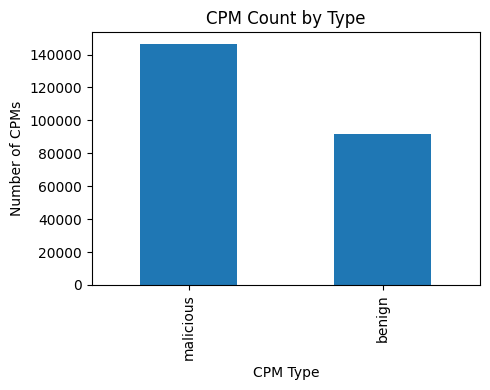

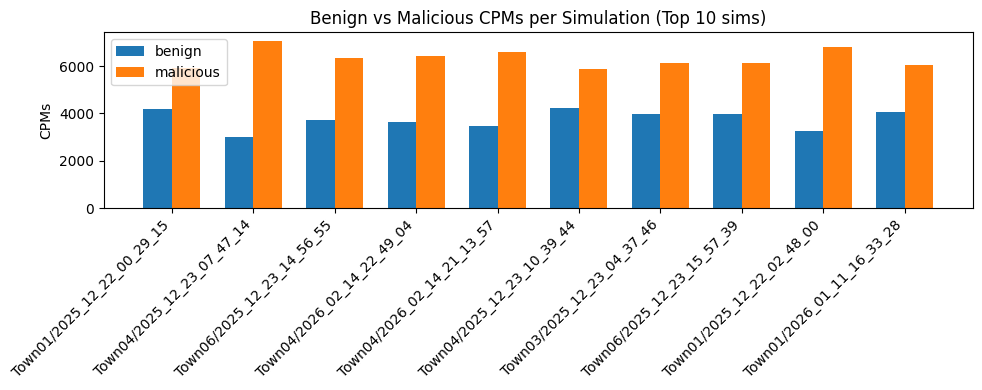

In [20]:
# 1.a Overall benign vs malicious CPM count
plt.figure(figsize=(5, 4))
counts = df_cpm["cpm_type"].value_counts(dropna=False)
counts.plot(kind="bar")
plt.title("CPM Count by Type")
plt.xlabel("CPM Type")
plt.ylabel("Number of CPMs")
plt.tight_layout()
plt.show()

# 1.b Per-simulation: benign vs malicious (top 10 sims by CPM count)
sim_type_counts = (
    df_cpm.groupby(["sim_name", "cpm_type"])
    .size()
    .unstack(fill_value=0)
)
top_sims = sim_type_counts.sum(axis=1).sort_values(ascending=False).head(10)
sim_type_counts_top = sim_type_counts.loc[top_sims.index]

plt.figure(figsize=(10, 4))
x = np.arange(len(sim_type_counts_top.index))
width = 0.35

benign_vals = sim_type_counts_top.get("benign", pd.Series(0, index=sim_type_counts_top.index))
mal_vals    = sim_type_counts_top.get("malicious", pd.Series(0, index=sim_type_counts_top.index))

plt.bar(x - width/2, benign_vals, width, label="benign")
plt.bar(x + width/2, mal_vals, width, label="malicious")

plt.xticks(x, sim_type_counts_top.index, rotation=45, ha="right")
plt.ylabel("CPMs")
plt.title("Benign vs Malicious CPMs per Simulation (Top 10 sims)")
plt.legend()
plt.tight_layout()
plt.show()


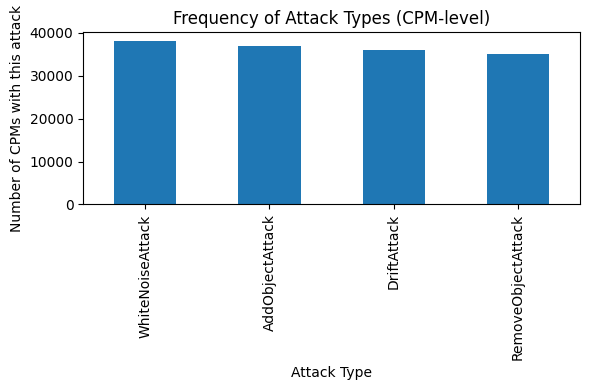

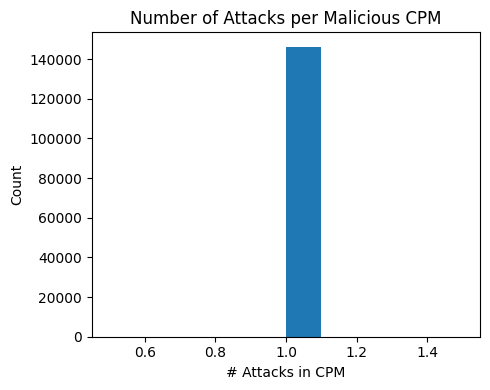

In [21]:
# 2.a CPM-level attack types frequency
def explode_attack_types(series):
    vals = []
    for s in series.dropna():
        for t in str(s).split(","):
            t = t.strip()
            if t:
                vals.append(t)
    return pd.Series(vals)

all_attack_types = explode_attack_types(df_cpm["attack_types"])
attack_type_counts = all_attack_types.value_counts()

plt.figure(figsize=(6, 4))
attack_type_counts.plot(kind="bar")
plt.title("Frequency of Attack Types (CPM-level)")
plt.xlabel("Attack Type")
plt.ylabel("Number of CPMs with this attack")
plt.tight_layout()
plt.show()

# 2.b How many attacks per malicious CPM?
plt.figure(figsize=(5, 4))
df_cpm.loc[df_cpm["is_malicious"], "num_attacks"].plot(kind="hist", bins=10)
plt.title("Number of Attacks per Malicious CPM")
plt.xlabel("# Attacks in CPM")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


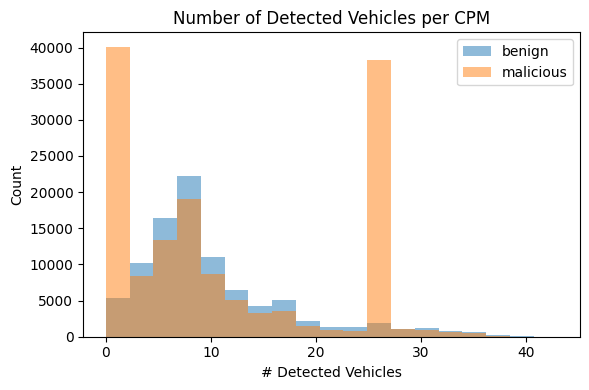

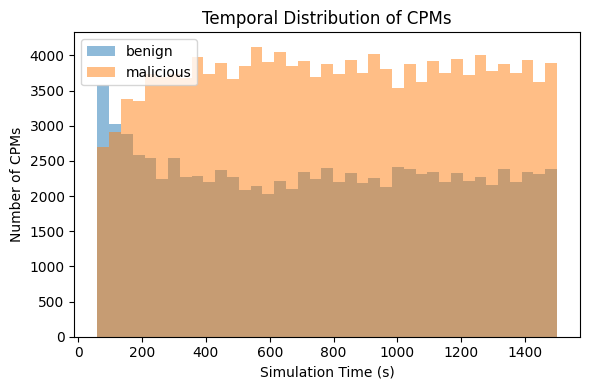

In [22]:
# 3.a Distribution of number of detected vehicles (benign vs malicious)
plt.figure(figsize=(6, 4))
bins = np.linspace(0, df_cpm["num_detected_vehicles"].max(), 20)

benign_nv = df_cpm.loc[df_cpm["is_malicious"] == False, "num_detected_vehicles"]
mal_nv    = df_cpm.loc[df_cpm["is_malicious"] == True, "num_detected_vehicles"]

plt.hist(benign_nv, bins=bins, alpha=0.5, label="benign")
plt.hist(mal_nv,    bins=bins, alpha=0.5, label="malicious")

plt.title("Number of Detected Vehicles per CPM")
plt.xlabel("# Detected Vehicles")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 3.b Distribution of CPM timestamps: benign vs malicious (global view)
plt.figure(figsize=(6, 4))
benign_t = df_cpm.loc[df_cpm["is_malicious"] == False, "timestamp"]
mal_t    = df_cpm.loc[df_cpm["is_malicious"] == True, "timestamp"]

bins = np.linspace(df_cpm["timestamp"].min(), df_cpm["timestamp"].max(), 40)

plt.hist(benign_t, bins=bins, alpha=0.5, label="benign")
plt.hist(mal_t,    bins=bins, alpha=0.5, label="malicious")

plt.title("Temporal Distribution of CPMs")
plt.xlabel("Simulation Time (s)")
plt.ylabel("Number of CPMs")
plt.legend()
plt.tight_layout()
plt.show()


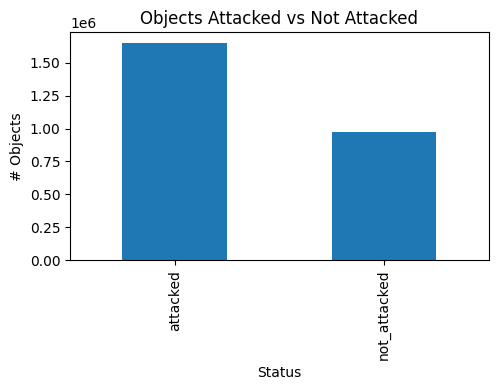

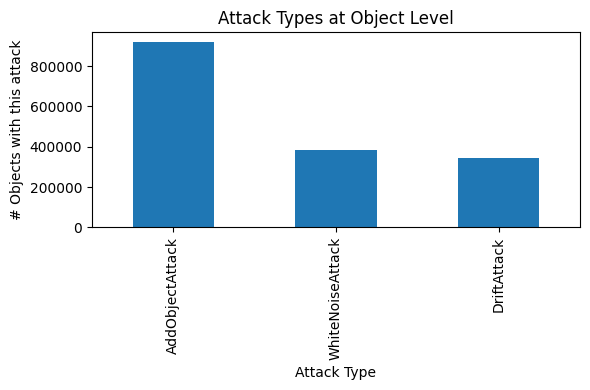

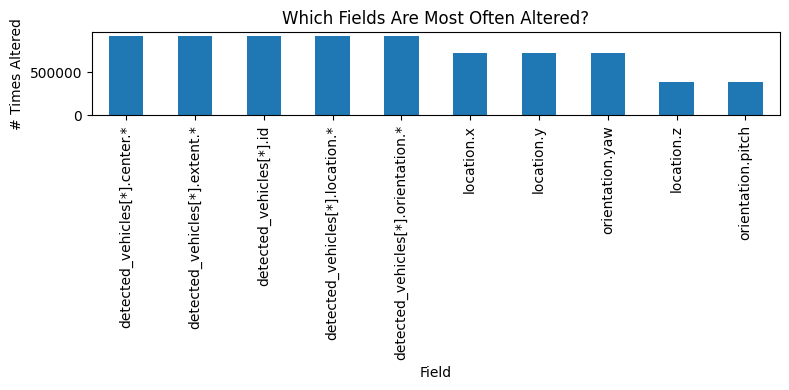

In [23]:
# 4.a Fraction of objects attacked vs not
plt.figure(figsize=(5, 4))
obj_counts = df_veh["obj_attacked"].value_counts()
obj_counts.index = obj_counts.index.map({True: "attacked", False: "not_attacked"})
obj_counts.plot(kind="bar")
plt.title("Objects Attacked vs Not Attacked")
plt.xlabel("Status")
plt.ylabel("# Objects")
plt.tight_layout()
plt.show()

# 4.b Attack types at object level
def explode_obj_attack_types(series):
    vals = []
    for s in series.dropna():
        for t in str(s).split(","):
            t = t.strip()
            if t:
                vals.append(t)
    return pd.Series(vals)

obj_attack_types_all = explode_obj_attack_types(df_veh["obj_attack_types"])
obj_attack_type_counts = obj_attack_types_all.value_counts()

plt.figure(figsize=(6, 4))
obj_attack_type_counts.plot(kind="bar")
plt.title("Attack Types at Object Level")
plt.xlabel("Attack Type")
plt.ylabel("# Objects with this attack")
plt.tight_layout()
plt.show()

# 4.c Altered fields frequency (object-level)
def explode_fields(series):
    vals = []
    for s in series.dropna():
        for t in str(s).split(","):
            t = t.strip()
            if t:
                vals.append(t)
    return pd.Series(vals)

obj_altered_fields_all = explode_fields(df_veh["obj_altered_fields"])
field_counts = obj_altered_fields_all.value_counts()

plt.figure(figsize=(8, 4))
field_counts.plot(kind="bar")
plt.title("Which Fields Are Most Often Altered?")
plt.xlabel("Field")
plt.ylabel("# Times Altered")
plt.tight_layout()
plt.show()


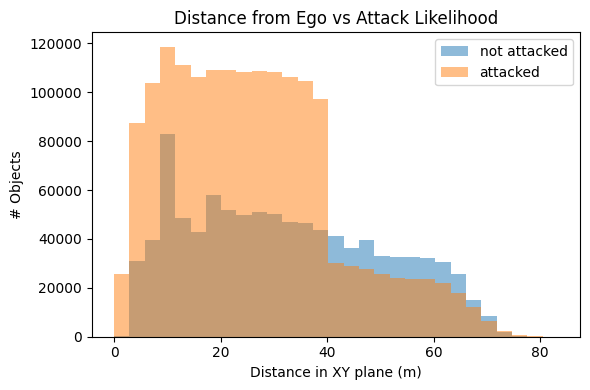

In [24]:
# 5.a Merge global position into df_veh
df_cpm_pos = df_cpm[["sim_name", "cpm_file", "global_x", "global_y", "global_z"]]
df_veh_with_pos = df_veh.merge(
    df_cpm_pos,
    on=["sim_name", "cpm_file"],
    how="left",
)

# 5.b Compute radial distance in XY plane
dx = df_veh_with_pos["loc_x"] - df_veh_with_pos["global_x"]
dy = df_veh_with_pos["loc_y"] - df_veh_with_pos["global_y"]
df_veh_with_pos["dist_xy"] = np.sqrt(dx**2 + dy**2)

# 5.c Compare distance distributions (attacked vs not)
attacked = df_veh_with_pos.loc[df_veh_with_pos["obj_attacked"] == True, "dist_xy"].dropna()
not_attacked = df_veh_with_pos.loc[df_veh_with_pos["obj_attacked"] == False, "dist_xy"].dropna()

plt.figure(figsize=(6, 4))
bins = np.linspace(0, df_veh_with_pos["dist_xy"].max(), 30)

plt.hist(not_attacked, bins=bins, alpha=0.5, label="not attacked")
plt.hist(attacked,     bins=bins, alpha=0.5, label="attacked")

plt.title("Distance from Ego vs Attack Likelihood")
plt.xlabel("Distance in XY plane (m)")
plt.ylabel("# Objects")
plt.legend()
plt.tight_layout()
plt.show()


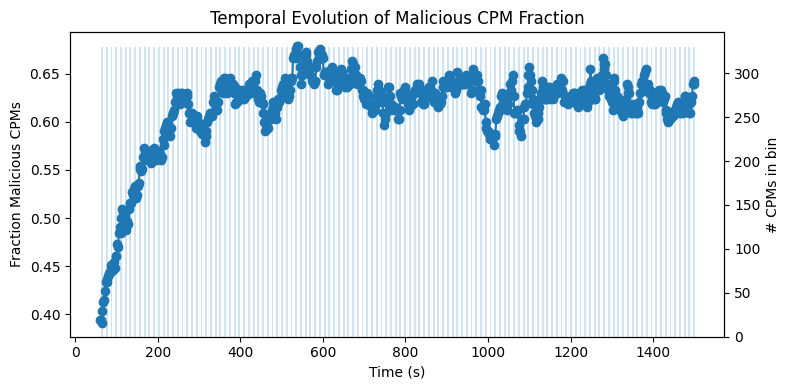

In [25]:
# 6.a Fraction of malicious CPMs over time (global)
df_cpm_time = df_cpm.copy()
# bucket timestamps into 1-second bins (or choose your bin width)
df_cpm_time["time_bin"] = df_cpm_time["timestamp"].astype(float).round()

agg = df_cpm_time.groupby("time_bin")["is_malicious"].agg(["mean", "count"])
# 'mean' is fraction malicious, 'count' is number of CPMs in that bin

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(agg.index, agg["mean"], marker="o")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Fraction Malicious CPMs")
ax1.set_title("Temporal Evolution of Malicious CPM Fraction")

ax2 = ax1.twinx()
ax2.bar(agg.index, agg["count"], alpha=0.2)
ax2.set_ylabel("# CPMs in bin")

fig.tight_layout()
plt.show()


In [26]:
# ---------- small helpers ----------

def _split_attack_types(series: pd.Series) -> list[str]:
    out = []
    for s in series.dropna():
        for t in str(s).split(","):
            t = t.strip()
            if t:
                out.append(t)
    return out

def _split_fields(series: pd.Series) -> list[str]:
    out = []
    for s in series.dropna():
        for t in str(s).split(","):
            t = t.strip()
            if t:
                out.append(t)
    return out

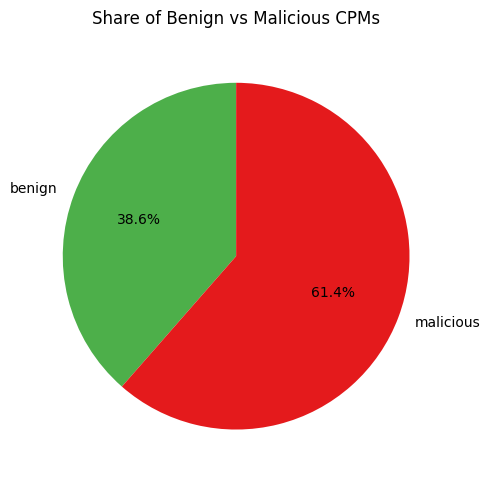

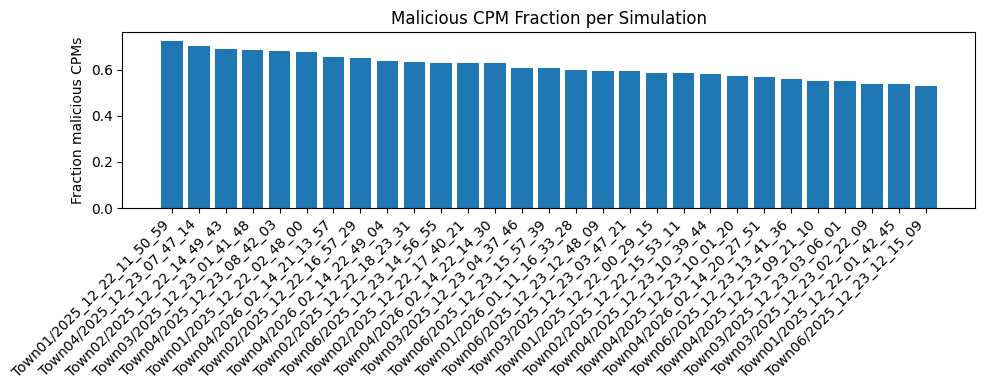

In [27]:
# =============== 1. GLOBAL OVERVIEW ===============

# 1.1 Pie: benign vs malicious CPMs
plt.figure(figsize=(5,5))
labels = ["benign", "malicious"]
sizes  = [
    (df_cpm["is_malicious"] == False).sum(),
    (df_cpm["is_malicious"] == True).sum(),
]
colors = ["#4daf4a", "#e41a1c"]

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
)
plt.title("Share of Benign vs Malicious CPMs")
plt.axis("equal")
plt.tight_layout()
plt.show()

# 1.2 Per-simulation malicious fraction (sorted)
sim_mal_frac = (
    df_cpm.groupby("sim_name")["is_malicious"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,4))
x = np.arange(len(sim_mal_frac))
plt.bar(x, sim_mal_frac.values)
plt.xticks(x, sim_mal_frac.index, rotation=45, ha="right")
plt.ylabel("Fraction malicious CPMs")
plt.title("Malicious CPM Fraction per Simulation")
plt.tight_layout()
plt.show()

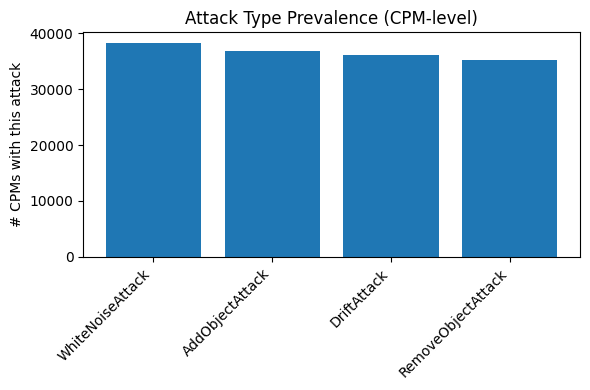

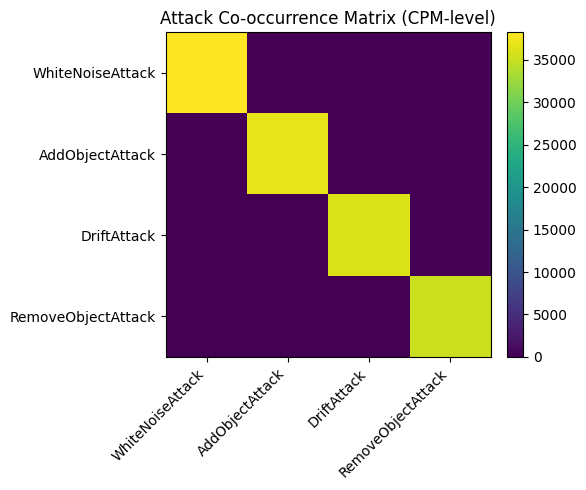

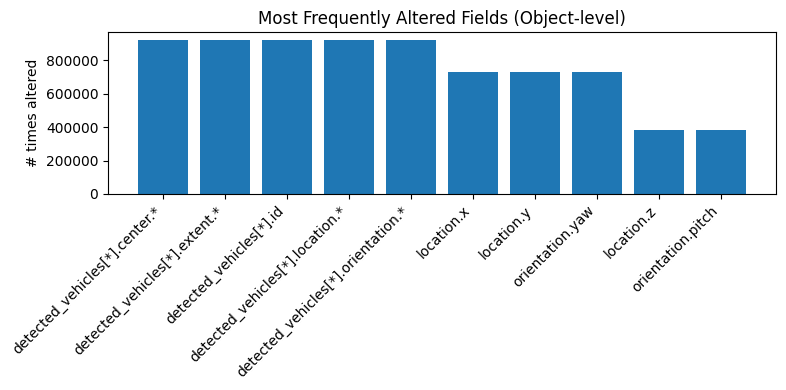

In [28]:
# =============== 2. ATTACK LANDSCAPE ===============

# 2.1 Attack type prevalence (CPM-level) – bar
all_attack_types = _split_attack_types(df_cpm["attack_types"])
attack_type_counts = pd.Series(all_attack_types).value_counts()

plt.figure(figsize=(6,4))
plt.bar(attack_type_counts.index, attack_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("# CPMs with this attack")
plt.title("Attack Type Prevalence (CPM-level)")
plt.tight_layout()
plt.show()

# 2.2 Attack co-occurrence heatmap (which attacks tend to appear together)
unique_types = list(attack_type_counts.index)
type_to_idx = {t: i for i, t in enumerate(unique_types)}
cooc = np.zeros((len(unique_types), len(unique_types)), dtype=int)

for s in df_cpm["attack_types"].dropna():
    types = {t.strip() for t in str(s).split(",") if t.strip()}
    types = [t for t in types if t in type_to_idx]
    for i in range(len(types)):
        for j in range(i, len(types)):
            a, b = types[i], types[j]
            ia, ib = type_to_idx[a], type_to_idx[b]
            cooc[ia, ib] += 1
            if ia != ib:
                cooc[ib, ia] += 1

plt.figure(figsize=(6,5))
im = plt.imshow(cooc, interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(unique_types)), unique_types, rotation=45, ha="right")
plt.yticks(range(len(unique_types)), unique_types)
plt.title("Attack Co-occurrence Matrix (CPM-level)")
plt.tight_layout()
plt.show()

# 2.3 Which fields are most often altered? (object-level)
obj_altered_fields_all = _split_fields(df_veh["obj_altered_fields"])
field_counts = pd.Series(obj_altered_fields_all).value_counts()

plt.figure(figsize=(8,4))
plt.bar(field_counts.index, field_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("# times altered")
plt.title("Most Frequently Altered Fields (Object-level)")
plt.tight_layout()
plt.show()

/var/folders/my/xy5c69yx4yx9rtwftvb5bqym0000gn/T/ipykernel_14686/1678482183.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["benign", "malicious"], showfliers=False)


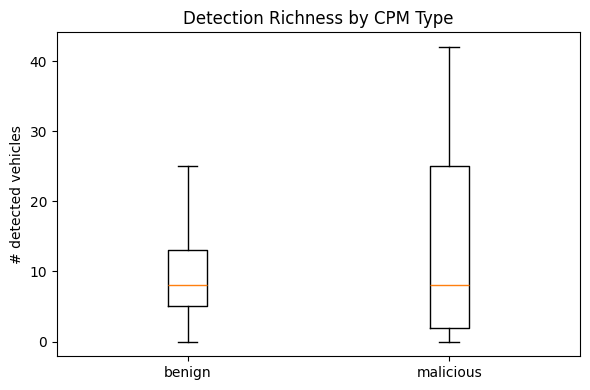

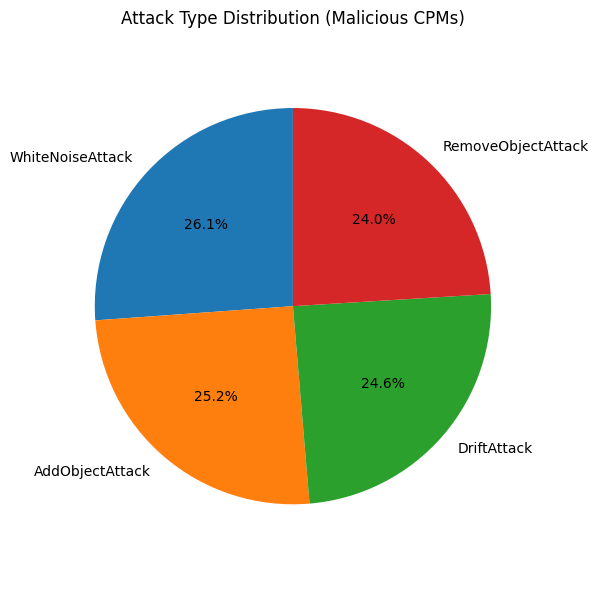

In [29]:
# =============== 3. CPM CONTENT & RICHNESS ===============

# 3.1 Boxplot: #detected vehicles by CPM type
data = [
    df_cpm.loc[df_cpm["cpm_type"] == "benign",    "num_detected_vehicles"].dropna(),
    df_cpm.loc[df_cpm["cpm_type"] == "malicious", "num_detected_vehicles"].dropna(),
]
plt.figure(figsize=(6,4))
plt.boxplot(data, labels=["benign", "malicious"], showfliers=False)
plt.ylabel("# detected vehicles")
plt.title("Detection Richness by CPM Type")
plt.tight_layout()
plt.show()

# 3.2 Pie: distribution of attack types among malicious CPMs only
mal_types = _split_attack_types(
    df_cpm.loc[df_cpm["is_malicious"] == True, "attack_types"]
)
if mal_types:
    mal_counts = pd.Series(mal_types).value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(
        mal_counts.values,
        labels=mal_counts.index,
        autopct="%1.1f%%",
        startangle=90,
    )
    plt.title("Attack Type Distribution (Malicious CPMs)")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

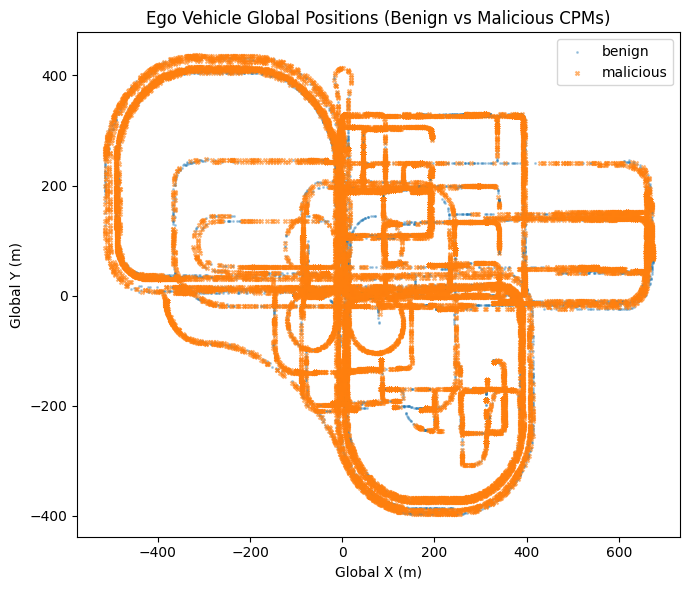

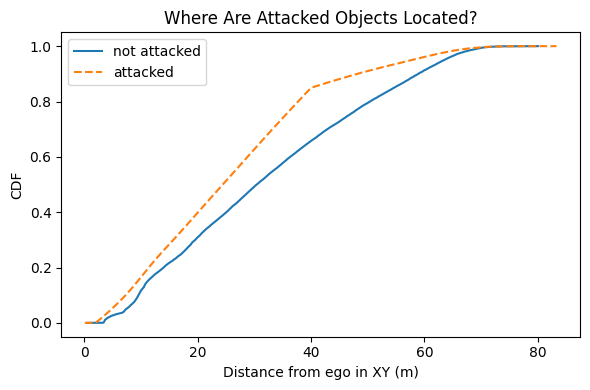

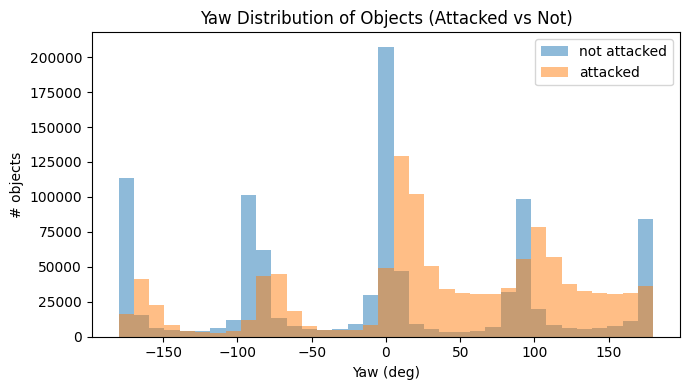

In [30]:
# =============== 4. SPATIAL PATTERNS (EGO & OBJECTS) ===============

# 4.1 Ego position map: benign vs malicious CPMs in global XY
sample_size = min(len(df_cpm), 50000)
df_sample = df_cpm.sample(sample_size, random_state=0) if len(df_cpm) > sample_size else df_cpm.copy()

ben = df_sample[df_sample["is_malicious"] == False]
mal = df_sample[df_sample["is_malicious"] == True]

plt.figure(figsize=(7,6))
plt.scatter(
    ben["global_x"], ben["global_y"],
    s=5, alpha=0.3, label="benign", marker="."
)
plt.scatter(
    mal["global_x"], mal["global_y"],
    s=8, alpha=0.6, label="malicious", marker="x"
)
plt.xlabel("Global X (m)")
plt.ylabel("Global Y (m)")
plt.title("Ego Vehicle Global Positions (Benign vs Malicious CPMs)")
plt.legend()
plt.tight_layout()
plt.show()

# 4.2 Object distance from ego: CDF for attacked vs not attacked
# recompute df_veh_with_pos if needed
if "global_x" not in df_veh.columns:
    df_cpm_pos = df_cpm[["sim_name", "cpm_file", "global_x", "global_y", "global_z"]]
    df_veh_with_pos = df_veh.merge(df_cpm_pos, on=["sim_name", "cpm_file"], how="left")
else:
    df_veh_with_pos = df_veh.copy()

dx = df_veh_with_pos["loc_x"] - df_veh_with_pos["global_x"]
dy = df_veh_with_pos["loc_y"] - df_veh_with_pos["global_y"]
df_veh_with_pos["dist_xy"] = np.sqrt(dx**2 + dy**2)

attacked = df_veh_with_pos.loc[df_veh_with_pos["obj_attacked"] == True, "dist_xy"].dropna().values
not_attacked = df_veh_with_pos.loc[df_veh_with_pos["obj_attacked"] == False, "dist_xy"].dropna().values

plt.figure(figsize=(6,4))
for arr, label, style in [
    (np.sort(not_attacked), "not attacked", "-"),
    (np.sort(attacked),     "attacked", "--"),
]:
    if len(arr) == 0:
        continue
    y = np.linspace(0, 1, len(arr))
    plt.plot(arr, y, style, label=label)

plt.xlabel("Distance from ego in XY (m)")
plt.ylabel("CDF")
plt.title("Where Are Attacked Objects Located?")
plt.legend()
plt.tight_layout()
plt.show()

# 4.3 Object yaw distribution: attacked vs not attacked (orientation bias)
att_yaw  = df_veh_with_pos.loc[df_veh_with_pos["obj_attacked"] == True, "yaw"].dropna()
non_yaw  = df_veh_with_pos.loc[df_veh_with_pos["obj_attacked"] == False, "yaw"].dropna()

bins = np.linspace(-180, 180, 36)
plt.figure(figsize=(7,4))
plt.hist(non_yaw, bins=bins, alpha=0.5, label="not attacked")
plt.hist(att_yaw, bins=bins, alpha=0.5, label="attacked")
plt.xlabel("Yaw (deg)")
plt.ylabel("# objects")
plt.title("Yaw Distribution of Objects (Attacked vs Not)")
plt.legend()
plt.tight_layout()
plt.show()

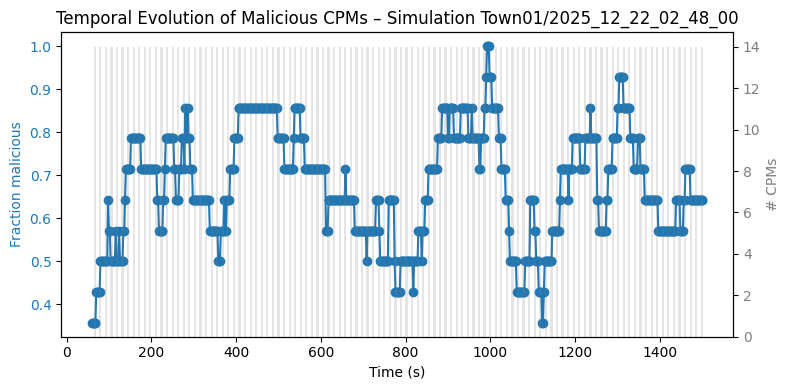

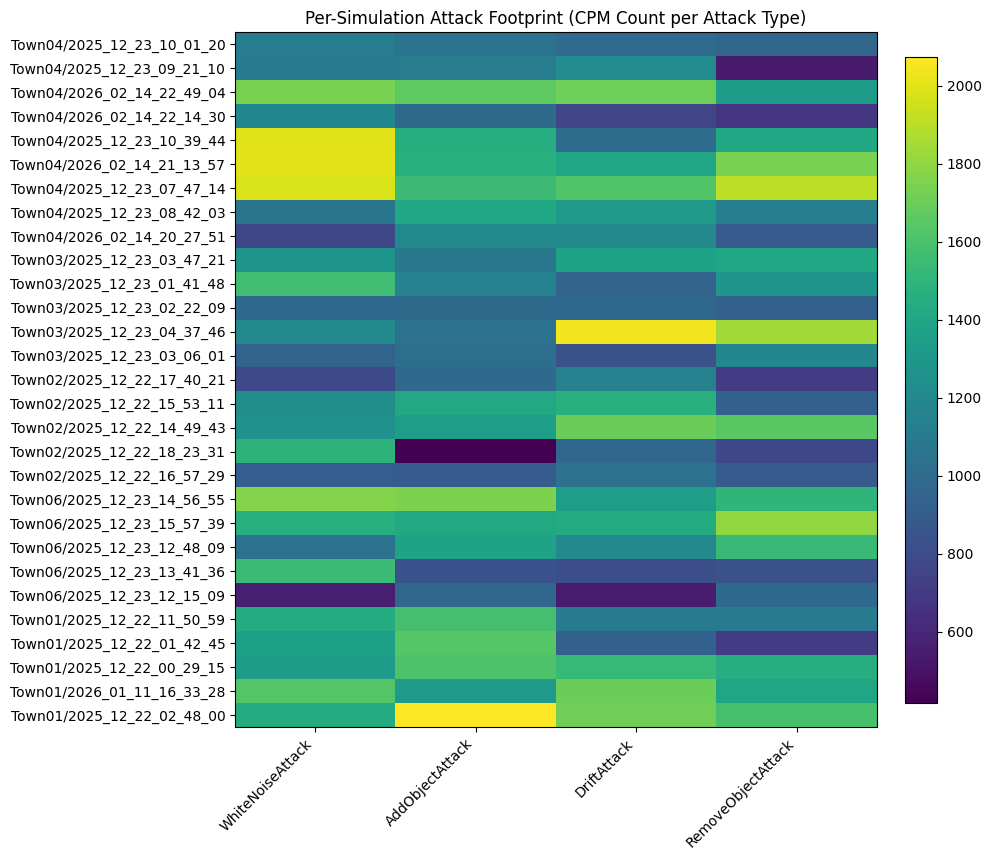

In [31]:
# =============== 5. TEMPORAL DYNAMICS ===============

# 5.1 Per-simulation: malicious fraction over time for one "interesting" simulation

# pick the sim with most CPMs as a representative
sim_counts = df_cpm["sim_name"].value_counts()
if len(sim_counts) > 0:
    top_sim = sim_counts.index[0]
    df_sim = df_cpm[df_cpm["sim_name"] == top_sim].copy()
    df_sim["time_bin"] = df_sim["timestamp"].astype(float).round()

    agg = df_sim.groupby("time_bin")["is_malicious"].agg(["mean", "count"])

    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.plot(agg.index, agg["mean"], marker="o")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Fraction malicious", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_title(f"Temporal Evolution of Malicious CPMs – Simulation {top_sim}")

    ax2 = ax1.twinx()
    ax2.bar(agg.index, agg["count"], alpha=0.2, color="tab:gray")
    ax2.set_ylabel("# CPMs", color="tab:gray")
    ax2.tick_params(axis="y", labelcolor="tab:gray")

    fig.tight_layout()
    plt.show()

# 5.2 Per-simulation "attack footprint": how many CPMs are attacked, by attack type

# build per-simulation x attack-type matrix
sim_attack_matrix = []

for sim in df_cpm["sim_name"].unique():
    tmp = df_cpm[df_cpm["sim_name"] == sim]
    types_here = _split_attack_types(tmp["attack_types"])
    counts_here = pd.Series(types_here).value_counts()
    row = {"sim_name": sim}
    for t in unique_types:
        row[t] = counts_here.get(t, 0)
    sim_attack_matrix.append(row)

df_sim_attacks = pd.DataFrame(sim_attack_matrix).set_index("sim_name")

plt.figure(figsize=(10, max(3, len(df_sim_attacks)*0.3)))
im = plt.imshow(df_sim_attacks.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(df_sim_attacks.columns)), df_sim_attacks.columns, rotation=45, ha="right")
plt.yticks(range(len(df_sim_attacks.index)), df_sim_attacks.index)
plt.title("Per-Simulation Attack Footprint (CPM Count per Attack Type)")
plt.tight_layout()
plt.show()


# Dataset Preprocessing

In [32]:
# -----------------------------
# Config
# -----------------------------
SEQ_LEN = 5          # window size W (change as you like)
MAX_OBJECTS = 35     # max detected vehicles per CPM
OBJ_FEATURES = ["loc_x", "loc_y", "yaw"]  # per-object features
N_OBJ_FEATS = len(OBJ_FEATURES)
FEATURE_DIM = MAX_OBJECTS * N_OBJ_FEATS   # 35 * 3 = 105

In [33]:
# -----------------------------
# 1) Prepare df_veh
# -----------------------------
df_veh_proc = df_veh.copy()
df_veh_proc["cpm_attack_types"] = df_veh_proc["cpm_attack_types"].fillna("").astype(str)

def _parse_cpm_filename(cpm_file: str) -> tuple[str, str]:
    """
    Parse filename into (run_id, ego_id_from_name).
    Supports both:
      - r000_<ego_id>_<timestamp>.yaml
      - <ego_id>_<timestamp>.yaml (legacy, assumed run_id=r000)
    """
    stem = Path(str(cpm_file)).stem
    parts = stem.split("_")
    if len(parts) >= 3 and parts[0].startswith("r") and parts[0][1:].isdigit():
        run_id = parts[0]
        ego_id = "_".join(parts[1:-1])
    elif len(parts) >= 2:
        run_id = "r000"
        ego_id = "_".join(parts[:-1])
    else:
        run_id = "r000"
        ego_id = stem
    return run_id, ego_id

# Parse filename metadata once per unique file (faster than row-wise parsing).
name_meta = {}
for name in df_veh_proc["cpm_file"].dropna().unique():
    run_id, ego_from_name = _parse_cpm_filename(name)
    name_meta[name] = {"run_id": run_id, "ego_from_name": ego_from_name}

if name_meta:
    df_name_meta = (
        pd.DataFrame.from_dict(name_meta, orient="index")
        .rename_axis("cpm_file")
        .reset_index()
    )
    df_veh_proc = df_veh_proc.merge(df_name_meta, on="cpm_file", how="left")
else:
    df_veh_proc["run_id"] = "r000"
    df_veh_proc["ego_from_name"] = ""

df_veh_proc["run_id"] = df_veh_proc["run_id"].fillna("r000").astype(str)

# Prefer ego ID from CPM content, fallback to filename parsing if missing.
df_veh_proc["orig_ego_id"] = df_veh_proc["ego_vehicle_id"]
missing_ego = df_veh_proc["orig_ego_id"].isna() | (df_veh_proc["orig_ego_id"].astype(str).str.strip() == "")
df_veh_proc.loc[missing_ego, "orig_ego_id"] = df_veh_proc.loc[missing_ego, "ego_from_name"]
df_veh_proc["orig_ego_id"] = df_veh_proc["orig_ego_id"].astype(str)

# ensure numeric timestamp & label
df_veh_proc["timestamp"] = df_veh_proc["timestamp"].astype(float)
df_veh_proc["y"] = df_veh_proc["cpm_is_malicious"].astype(int)

# fill NaNs in object features with 0
df_veh_proc[OBJ_FEATURES] = df_veh_proc[OBJ_FEATURES].fillna(0.0)

# sort nicely
df_veh_proc = df_veh_proc.sort_values(
    ["sim_name", "run_id", "orig_ego_id", "timestamp", "obj_rank"]
).reset_index(drop=True)

In [34]:
def extract_attack_types_for_frame(cpm_attack_series: pd.Series) -> list[str]:
    """
    Given the cpm_attack_types column for one timestamp (all rows same CPM),
    return a sorted list of unique attack types, e.g. ["DriftAttack", "AddObjectAttack"].
    """
    types = set()
    for val in cpm_attack_series:
        s = str(val).strip()
        if not s:
            continue
        for t in s.split(","):
            t = t.strip()
            if t:
                types.add(t)
    return sorted(types)

In [35]:
# -----------------------------
# 2) Build per-frame feature vectors
# -----------------------------
def build_frame_list_for_group(g: pd.DataFrame):
    """
    For one (sim_name, orig_ego_id) group:
      - group by timestamp
      - for each timestamp, build a feature vector of size FEATURE_DIM
        using top MAX_OBJECTS (by obj_rank) and padding with zeros.
    Returns:
      frames: list of dicts with keys:
        - "timestamp"
        - "features" (np.array of shape (FEATURE_DIM,))
        - "y" (0/1 malicious label for that CPM)
        - "attack_types" (list[str] for that CPM)
    """
    frames = []

    # group by timestamp inside this vehicle
    for ts, g_ts in g.groupby("timestamp"):
        # sort by obj_rank and keep at most MAX_OBJECTS
        g_ts = g_ts.sort_values("obj_rank").head(MAX_OBJECTS)

        # initialize [MAX_OBJECTS, N_OBJ_FEATS] with zeros
        feats = np.zeros((MAX_OBJECTS, N_OBJ_FEATS), dtype=np.float32)

        # how many objects are actually present
        k = len(g_ts)

        if k > 0:
            feats[:k, 0] = g_ts["loc_x"].to_numpy(dtype="float32")
            feats[:k, 1] = g_ts["loc_y"].to_numpy(dtype="float32")
            feats[:k, 2] = g_ts["yaw"].to_numpy(dtype="float32")

            label = int(g_ts["y"].iloc[0])
        else:
            label = 0  # rare corner case

        # NEW: per-frame attack types from cpm_attack_types column
        frame_attack_types = extract_attack_types_for_frame(g_ts["cpm_attack_types"])

        frames.append(
            {
                "timestamp": float(ts),
                "features": feats.reshape(-1),  # (FEATURE_DIM,)
                "y": label,
                "attack_types": frame_attack_types,
            }
        )

    frames.sort(key=lambda d: d["timestamp"])
    return frames

In [36]:
# -----------------------------
# 3) Build sequences across all sims / vehicles
# -----------------------------
X_list = []
y_list = []
meta_list = []

for (sim, run_id, vid), g in df_veh_proc.groupby(["sim_name", "run_id", "orig_ego_id"]):
    frames = build_frame_list_for_group(g)
    if len(frames) < SEQ_LEN:
        continue

    for i in range(len(frames) - SEQ_LEN + 1):
        window = frames[i : i + SEQ_LEN]

        X_seq = np.stack([f["features"] for f in window], axis=0)
        y_seq = window[-1]["y"]

        # NEW: union of attack types over the whole window
        seq_attack_set = set()
        for f in window:
            for t in f.get("attack_types", []):
                seq_attack_set.add(t)

        seq_attack_types = sorted(seq_attack_set)
        seq_attack_types_str = ",".join(seq_attack_types) if seq_attack_types else None

        X_list.append(X_seq)
        y_list.append(y_seq)

        meta_list.append(
            {
                "sim_name": sim,
                "run_id": run_id,
                "orig_ego_id": vid,
                "seq_idx_in_vehicle": i,
                "start_timestamp": window[0]["timestamp"],
                "end_timestamp": window[-1]["timestamp"],
                "label": y_seq,
                # NEW: sequence-level attack info
                "seq_attack_types": seq_attack_types_str,
            }
        )

In [37]:
# -----------------------------
# 4) Final arrays + metadata DF
# -----------------------------
if X_list:
    X = np.stack(X_list, axis=0)           # (num_sequences, SEQ_LEN, FEATURE_DIM)
    y = np.array(y_list, dtype="int64")    # (num_sequences,)
else:
    X = np.empty((0, SEQ_LEN, FEATURE_DIM), dtype="float32")
    y = np.empty((0,), dtype="int64")

df_seq_meta = pd.DataFrame(meta_list)

print("X shape:", X.shape)    # expect (N, W, 105)
print("y shape:", y.shape)
df_seq_meta.head()

X shape: (233364, 5, 105)
y shape: (233364,)


,sim_name,run_id,orig_ego_id,seq_idx_in_vehicle,start_timestamp,end_timestamp,label,seq_attack_types
0,Town01/2025_12_22_00_29_15,r000,5749,0,60.0,68.0,1,AddObjectAttack
1,Town01/2025_12_22_00_29_15,r000,5749,1,62.0,70.0,1,AddObjectAttack
2,Town01/2025_12_22_00_29_15,r000,5749,2,64.0,72.0,1,AddObjectAttack
3,Town01/2025_12_22_00_29_15,r000,5749,3,66.0,74.0,1,AddObjectAttack
4,Town01/2025_12_22_00_29_15,r000,5749,4,68.0,76.0,1,AddObjectAttack


### Checking if the dataset created is correct

In [38]:
print("X:", X.shape, X.dtype)   # (N, SEQ_LEN, FEATURE_DIM) float32
print("y:", y.shape, y.dtype)   # (N,) int64
print("meta:", df_seq_meta.shape)
assert X.shape[1] == SEQ_LEN
assert X.shape[2] == FEATURE_DIM
assert set(np.unique(y)).issubset({0,1})


X: (233364, 5, 105) float32
y: (233364,) int64
meta: (233364, 8)


In [39]:
# timestamps in meta should match window start/end
assert (df_seq_meta["end_timestamp"] >= df_seq_meta["start_timestamp"]).all()

# spot-check random sequences for monotonic timestamps (reconstruct from source)
import random
idxs = random.sample(range(len(df_seq_meta)), k=min(20, len(df_seq_meta)))
for idx in idxs:
    m = df_seq_meta.iloc[idx]
    g = df_veh_proc[(df_veh_proc.sim_name==m.sim_name) & (df_veh_proc.run_id==m.run_id) & (df_veh_proc.orig_ego_id==m.orig_ego_id)]
    ts_sorted = np.sort(g["timestamp"].unique())
    win_ts = ts_sorted[m.seq_idx_in_vehicle : m.seq_idx_in_vehicle + SEQ_LEN]
    assert len(win_ts) == SEQ_LEN
    assert np.all(np.diff(win_ts) >= 0)
    assert float(win_ts[0]) == float(m.start_timestamp)
    assert float(win_ts[-1]) == float(m.end_timestamp)
print("Timestamp alignment OK")


Timestamp alignment OK


In [40]:
if len(df_seq_meta) == 0:
    print("No sequences available for frame-feature validation.")
else:
    idx = np.random.randint(len(df_seq_meta))
    m = df_seq_meta.iloc[idx]

    g = df_veh_proc[(df_veh_proc.sim_name==m.sim_name) & (df_veh_proc.run_id==m.run_id) & (df_veh_proc.orig_ego_id==m.orig_ego_id)]
    ts_sorted = np.sort(g["timestamp"].unique())
    ts0 = ts_sorted[m.seq_idx_in_vehicle]  # first frame timestamp in this sequence

    g_ts = g[g["timestamp"]==ts0].sort_values("obj_rank").head(MAX_OBJECTS)

    # rebuild frame vector directly
    feats = np.zeros((MAX_OBJECTS, N_OBJ_FEATS), dtype=np.float32)
    k = len(g_ts)
    feats[:k, 0] = g_ts["loc_x"].to_numpy(np.float32)
    feats[:k, 1] = g_ts["loc_y"].to_numpy(np.float32)
    feats[:k, 2] = g_ts["yaw"].to_numpy(np.float32)
    frame_vec = feats.reshape(-1)

    # compare to stored X
    np.testing.assert_allclose(frame_vec, X[idx, 0], rtol=0, atol=1e-6)

    # verify padding is zeros after k objects
    assert np.allclose(feats[k:], 0.0)
    print("Frame feature build OK, k =", k)


Frame feature build OK, k = 25


In [41]:
# check several random sequences
for idx in np.random.choice(len(df_seq_meta), size=min(50, len(df_seq_meta)), replace=False):
    m = df_seq_meta.iloc[idx]
    g = df_veh_proc[(df_veh_proc.sim_name==m.sim_name) & (df_veh_proc.run_id==m.run_id) & (df_veh_proc.orig_ego_id==m.orig_ego_id)]
    ts_sorted = np.sort(g["timestamp"].unique())
    ts_last = ts_sorted[m.seq_idx_in_vehicle + SEQ_LEN - 1]
    y_last = int(g[g["timestamp"]==ts_last]["y"].iloc[0])
    assert y[idx] == y_last
    assert m["label"] == y_last
print("Labels match last frame OK")


Labels match last frame OK


In [42]:
if len(df_seq_meta) == 0:
    print("No sequences available for attack-union validation.")
else:
    idx = np.random.randint(len(df_seq_meta))
    m = df_seq_meta.iloc[idx]

    g = df_veh_proc[(df_veh_proc.sim_name==m.sim_name) & (df_veh_proc.run_id==m.run_id) & (df_veh_proc.orig_ego_id==m.orig_ego_id)]
    ts_sorted = np.sort(g["timestamp"].unique())
    win_ts = ts_sorted[m.seq_idx_in_vehicle : m.seq_idx_in_vehicle + SEQ_LEN]

    def parse_types(s):
        s = str(s).strip()
        if not s:
            return []
        return [t.strip() for t in s.split(",") if t.strip()]

    union = set()
    for ts in win_ts:
        vals = g[g["timestamp"]==ts]["cpm_attack_types"]
        for v in vals:
            union.update(parse_types(v))

    expected = ",".join(sorted(union)) if union else None
    assert (m["seq_attack_types"] == expected) or (pd.isna(m["seq_attack_types"]) and expected is None)
    print("Attack union OK:", expected)


Attack union OK: DriftAttack,RemoveObjectAttack


In [43]:
display(df_seq_meta.sample(5))
print("Malicious rate:", y.mean())
print("Any NaNs in X?", np.isnan(X).any())


,sim_name,run_id,orig_ego_id,seq_idx_in_vehicle,start_timestamp,end_timestamp,label,seq_attack_types
134663,Town04/2025_12_23_08_42_03,r001,2422,624,1460.0,1468.0,0,AddObjectAttack
200103,Town06/2025_12_23_12_48_09,r000,4596,631,1322.0,1330.0,1,WhiteNoiseAttack
91423,Town03/2025_12_23_02_22_09,r001,595,381,822.0,830.0,1,DriftAttack
135186,Town04/2025_12_23_08_42_03,r001,2437,506,1072.0,1080.0,1,AddObjectAttack
9401,Town01/2025_12_22_00_29_15,r001,5837,130,320.0,328.0,1,WhiteNoiseAttack


Malicious rate: 0.6146192214737491
Any NaNs in X? False


In [44]:
df_seq_meta['seq_attack_types'].value_counts()

seq_attack_types
WhiteNoiseAttack                                       36384
AddObjectAttack                                        35605
DriftAttack                                            34063
RemoveObjectAttack                                     32392
DriftAttack,WhiteNoiseAttack                            2120
DriftAttack,RemoveObjectAttack                          1943
RemoveObjectAttack,WhiteNoiseAttack                     1906
AddObjectAttack,WhiteNoiseAttack                        1874
AddObjectAttack,DriftAttack                             1831
AddObjectAttack,RemoveObjectAttack                      1810
AddObjectAttack,DriftAttack,WhiteNoiseAttack              69
AddObjectAttack,RemoveObjectAttack,WhiteNoiseAttack       61
AddObjectAttack,DriftAttack,RemoveObjectAttack            54
DriftAttack,RemoveObjectAttack,WhiteNoiseAttack           41
Name: count, dtype: int64

We convert each CPM frame into a fixed-length numerical representation and then build short temporal sequences for learning. For every simulation run and ego vehicle, we group detections by timestamp and sort detected objects by their rank. From each timestamp we keep the top 𝑀 = 35 objects and extract three per-object kinematic attributes—relative position (𝑥, 𝑦) and yaw angle yielding a 35×3 matrix per frame. If fewer than 35 objects are present, the remaining rows are zero-padded to preserve a constant input size. This matrix is flattened into a 105-dimensional feature vector and used to form sliding windows of length 𝑊 = 5consecutive frames, producing sequences of shape 
(5, 105). Each sequence is labeled using the malicious/benign indicator of the last frame in the window, and we additionally store sequence metadata (simulation ID, ego ID, start/end timestamps) and the union of any attack-type annotations observed within the window.

# Models Creation

In [45]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)

## MODEL BUILDER FUNCTIONS

In [46]:
def build_lstm(seq_len, n_features, lstm_units=64, dense_units=32, dropout=0.3):
    """Build LSTM model for binary classification"""
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(lstm_units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [47]:
def build_transformer(seq_len, n_features, d_model=64, num_heads=4, 
                     ff_dim=128, num_layers=2, dropout=0.3):
    """Build Transformer (Encoder) model for binary classification"""
    
    def transformer_encoder(x, d_model, num_heads, ff_dim, dropout):
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )(x, x)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attn)
        ff = layers.Dense(ff_dim, activation="relu")(x)
        ff = layers.Dropout(dropout)(ff)
        ff = layers.Dense(d_model)(ff)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ff)
        return x
    
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Dense(d_model)(inp)
    pos = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)(pos)
    x = x + pos_emb
    x = layers.Dropout(dropout)(x)
    
    for _ in range(num_layers):
        x = transformer_encoder(x, d_model, num_heads, ff_dim, dropout)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    
    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [48]:
def build_transformer_v2(seq_len, n_features,
                         d_model=128, num_heads=4,
                         ff_dim=256, num_layers=3,
                         dropout=0.2, conv_kernel=3):
    """Transformer + Conv1D + Attention Pooling (binary classification)"""

    def encoder_block(x):
        # Pre-norm self-attention
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )(x1, x1)
        x = layers.Add()([x, layers.Dropout(dropout)(attn)])

        # Pre-norm FFN
        x2 = layers.LayerNormalization(epsilon=1e-6)(x)
        ff = layers.Dense(ff_dim, activation="gelu")(x2)
        ff = layers.Dropout(dropout)(ff)
        ff = layers.Dense(d_model)(ff)
        x = layers.Add()([x, layers.Dropout(dropout)(ff)])
        return x

    inp = layers.Input(shape=(seq_len, n_features))

    # Project features
    x = layers.Dense(d_model)(inp)

    # Positional embedding
    pos = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)(pos)
    x = x + pos_emb
    x = layers.Dropout(dropout)(x)

    # Lightweight reminder: short seq_len benefits from local mixing
    x = layers.Conv1D(filters=d_model, kernel_size=conv_kernel, padding="same", activation="gelu")(x)
    x = layers.Dropout(dropout)(x)

    # Transformer encoder stack
    for _ in range(num_layers):
        x = encoder_block(x)

    # Attention pooling over time
    scores = layers.Dense(1)(x)                          # (B, T, 1)
    weights = layers.Softmax(axis=1)(scores)             # (B, T, 1)
    x = layers.Multiply()([x, weights])
    x = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)

    # Head
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [49]:
def build_gru(seq_len, n_features, gru_units=64, dense_units=32, dropout=0.3):
    """Build GRU model for binary classification"""
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.GRU(gru_units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [50]:
def build_bilstm(seq_len, n_features, lstm_units=64, dense_units=32, dropout=0.3):
    """Build Bidirectional LSTM model for binary classification"""
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False)),
        layers.Dropout(dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [51]:
def build_cnn_lstm(seq_len, n_features, filters=64, kernel_size=3, 
                   lstm_units=64, dense_units=32, dropout=0.3):
    """Build CNN-LSTM hybrid model for binary classification"""
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(dropout),
        layers.LSTM(lstm_units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [52]:
def build_simple_cnn(seq_len, n_features, filters=64, kernel_size=3, dropout=0.3):
    """Build simple CNN model for binary classification"""
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(dropout),
        layers.Conv1D(filters=filters*2, kernel_size=kernel_size, activation="relu", padding="same"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

## UTILITY FUNCTIONS

In [53]:
def prepare_data(X, y, df_seq_meta, test_size=0.30, val_split=0.50, random_state=42):
    """Split data and apply scaling"""
    df_seq_meta = df_seq_meta.reset_index(drop=True)
    
    if len(y) == 0:
        raise ValueError("No sequences available for training. Build X/y first.")

    labels, counts = np.unique(y, return_counts=True)
    if len(labels) < 2:
        raise ValueError("Need both benign (0) and malicious (1) sequences for stratified splits.")
    if counts.min() < 3:
        raise ValueError("Each class needs at least 3 samples for train/val/test stratified splits.")
    
    # Split into train/temp
    X_train, X_tmp, y_train, y_tmp, meta_train, meta_tmp = train_test_split(
        X, y, df_seq_meta, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Split temp into val/test
    X_val, X_test, y_val, y_test, meta_val, meta_test = train_test_split(
        X_tmp, y_tmp, meta_tmp, test_size=val_split, random_state=random_state, stratify=y_tmp
    )
    
    # Scale
    seq_len = X_train.shape[1]
    n_features = X_train.shape[2]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(-1, seq_len, n_features)
    X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(-1, seq_len, n_features)
    X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(-1, seq_len, n_features)
    
    y_train = y_train.astype("float32")
    y_val = y_val.astype("float32")
    y_test = y_test.astype("float32")
    
    data_dict = {
        'X_train': X_train_scaled, 'X_val': X_val_scaled, 'X_test': X_test_scaled,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'meta_train': meta_train, 'meta_val': meta_val, 'meta_test': meta_test,
        'seq_len': seq_len, 'n_features': n_features
    }
    
    return data_dict

In [54]:
def compute_class_weights(y_train):
    """Compute class weights for imbalanced data"""
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)
    total = neg + pos
    if pos > 0 and neg > 0:
        weight_for_0 = total / (2.0 * neg)
        weight_for_1 = total / (2.0 * pos)
        return {0: weight_for_0, 1: weight_for_1}
    return None

In [55]:
def train_model(model, data_dict, class_weight=None, epochs=50, 
                batch_size=64, patience=5, verbose=1):
    """Train a model with early stopping"""
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )
    
    history = model.fit(
        data_dict['X_train'],
        data_dict['y_train'],
        validation_data=(data_dict['X_val'], data_dict['y_val']),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=verbose,
    )
    
    return history

In [56]:
def evaluate_model(model, data_dict):
    """Evaluate model and return metrics"""
    X_test = data_dict['X_test']
    y_test = data_dict['y_test']
    
    test_probs = model.predict(X_test, verbose=0).ravel()
    test_pred = (test_probs >= 0.5).astype(int)
    
    # Metrics
    # Force a 2x2 matrix even if one class is absent in the test split.
    cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, test_pred, average='binary', zero_division=0
    )
    
    acc = accuracy_score(y_test, test_pred)
    
    try:
        auc = roc_auc_score(y_test, test_probs)
    except ValueError:
        auc = None
    
    metrics = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'test_probs': test_probs,
        'test_pred': test_pred
    }
    
    return metrics

In [57]:
def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history.history["loss"], label="train loss")
    axes[0].plot(history.history["val_loss"], label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_name} - Training/Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history.history["accuracy"], label="train acc")
    axes[1].plot(history.history["val_accuracy"], label="val acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{model_name} - Training/Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [58]:
def plot_roc_curve(y_test, test_probs, auc, model_name):
    """Plot ROC curve"""
    if len(np.unique(y_test)) == 2 and auc is not None:
        fpr, tpr, _ = roc_curve(y_test, test_probs)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})", linewidth=2)
        plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} - ROC Curve (Test)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [59]:
def per_attack_evaluation(model, data_dict, verbose=True):
    """Evaluate model performance per attack type"""
    X_test = data_dict['X_test']
    y_test = data_dict['y_test']
    meta_test = data_dict['meta_test']
    
    probs_test = model.predict(X_test, verbose=0).ravel()
    pred_test = (probs_test >= 0.5).astype(int)
    
    df_eval = meta_test.copy().reset_index(drop=True)
    df_eval["y_true"] = y_test.astype(int)
    df_eval["y_prob"] = probs_test
    df_eval["y_pred"] = pred_test
    
    def parse_attack_list(val):
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return []
        if isinstance(val, list):
            return val
        s = str(val).strip()
        if not s:
            return []
        return [t.strip() for t in s.split(",") if t.strip()]
    
    df_eval["attack_list"] = df_eval["seq_attack_types"].apply(parse_attack_list)
    
    # Per-attack stats
    all_attack_types = sorted({t for lst in df_eval["attack_list"] for t in lst})
    rows = []
    
    for atk in all_attack_types:
        has_atk = df_eval["attack_list"].apply(lambda lst: atk in lst)
        sub = df_eval[has_atk & (df_eval["y_true"] == 1)]
        if len(sub) == 0:
            continue
        
        y_true_sub = sub["y_true"].values
        y_pred_sub = sub["y_pred"].values
        acc = accuracy_score(y_true_sub, y_pred_sub)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_sub, y_pred_sub, average="binary", zero_division=0
        )
        
        rows.append({
            "attack_type": atk,
            "num_seqs": len(sub),
            "acc": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
        })
    
    df_attack_stats = pd.DataFrame(rows, columns=["attack_type", "num_seqs", "acc", "precision", "recall", "f1"])
    if not df_attack_stats.empty:
        df_attack_stats = df_attack_stats.sort_values("acc", ascending=False)
    
    # Benign baseline
    mask_benign = (df_eval["y_true"] == 0) & df_eval["attack_list"].apply(lambda lst: len(lst) == 0)
    benign_acc = None
    if mask_benign.any():
        benign_acc = accuracy_score(df_eval.loc[mask_benign, "y_true"],
                                    df_eval.loc[mask_benign, "y_pred"])
    
    if verbose:
        print("\nPer-Attack Performance:")
        display(df_attack_stats)
        if benign_acc is not None:
            print(f"\nBenign sequences accuracy: {benign_acc:.3f}")
    
    return df_attack_stats, benign_acc

## Training

In [60]:
def train_and_evaluate_models(X, y, df_seq_meta, model_configs, 
                              epochs=50, batch_size=64, patience=5):
    """
    Train and evaluate multiple models
    
    Args:
        X: input features (3D array)
        y: labels
        df_seq_meta: metadata dataframe
        model_configs: dict of {model_name: builder_function}
        epochs: training epochs
        batch_size: batch size
        patience: early stopping patience
    
    Returns:
        results: dict containing all results for each model
    """
    
    # Prepare data once
    print("Preparing data...")
    data_dict = prepare_data(X, y, df_seq_meta)
    class_weight = compute_class_weights(data_dict['y_train'])
    print(f"Class weights: {class_weight}")
    print(f"Train: {len(data_dict['y_train'])}, Val: {len(data_dict['y_val'])}, Test: {len(data_dict['y_test'])}")
    
    results = {}
    comparison_data = []
    
    for model_name, builder_func in model_configs.items():
        print(f"\n{'='*60}")
        print(f"Training {model_name}")
        print(f"{'='*60}")
        
        # Build model
        model = builder_func(data_dict['seq_len'], data_dict['n_features'])
        print(f"\n{model_name} Architecture:")
        model.summary()
        
        # Train
        history = train_model(model, data_dict, class_weight, 
                            epochs=epochs, batch_size=batch_size, 
                            patience=patience, verbose=1)
        
        # Evaluate
        metrics = evaluate_model(model, data_dict)
        
        # Print results
        print(f"\n{model_name} Test Results:")
        print(f"Accuracy: {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall: {metrics['recall']:.4f}")
        print(f"F1-Score: {metrics['f1']:.4f}")
        if metrics['auc'] is not None:
            print(f"ROC AUC: {metrics['auc']:.4f}")
        print(f"Confusion Matrix: TN={metrics['tn']}, FP={metrics['fp']}, FN={metrics['fn']}, TP={metrics['tp']}")
        
        # Plots
        plot_training_curves(history, model_name)
        plot_roc_curve(data_dict['y_test'], metrics['test_probs'], 
                      metrics['auc'], model_name)
        
        # Per-attack evaluation
        attack_stats, benign_acc = per_attack_evaluation(model, data_dict)
        
        # Store results
        results[model_name] = {
            'model': model,
            'history': history,
            'metrics': metrics,
            'attack_stats': attack_stats,
            'benign_acc': benign_acc
        }
        
        # Collect for comparison
        comparison_data.append({
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1'],
            'ROC AUC': metrics['auc'] if metrics['auc'] is not None else np.nan,
            'Benign Acc': benign_acc if benign_acc is not None else np.nan
        })
    
    # Comparison table
    df_comparison = pd.DataFrame(comparison_data)
    
    print(f"\n{'='*60}")
    print("MODEL COMPARISON")
    print(f"{'='*60}")
    display(df_comparison.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-Score': '{:.4f}',
        'ROC AUC': '{:.4f}',
        'Benign Acc': '{:.4f}'
    }).background_gradient(cmap='YlGn', subset=['Accuracy', 'F1-Score', 'ROC AUC']))
    
    results['comparison_table'] = df_comparison
    
    return results

Preparing data...
Class weights: {0: np.float64(1.2974282401156418), 1: np.float64(0.8135078335873148)}
Train: 163354, Val: 35005, Test: 35005

Training LSTM

LSTM Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        43,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,633 (178.25 KB)

 Trainable params: 45,633 (178.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6711 - loss: 0.5427 - val_accuracy: 0.6908 - val_loss: 0.5219
Epoch 2/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7058 - loss: 0.4998 - val_accuracy: 0.7129 - val_loss: 0.4915
Epoch 3/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7246 - loss: 0.4792 - val_accuracy: 0.7398 - val_loss: 0.4677
Epoch 4/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7441 - loss: 0.4587 - val_accuracy: 0.7582 - val_loss: 0.4497
Epoch 5/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7609 - loss: 0.4418 - val_accuracy: 0.7755 - val_loss: 0.4264
Epoch 6/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7736 - loss: 0.4259 - val_accuracy: 0.7855 - val_loss: 0.4175
Epoch 7/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7862 - loss: 0.4118 - val_accuracy: 0.7883 - val_loss: 0.4061
Epoch 8/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7956 - loss: 0

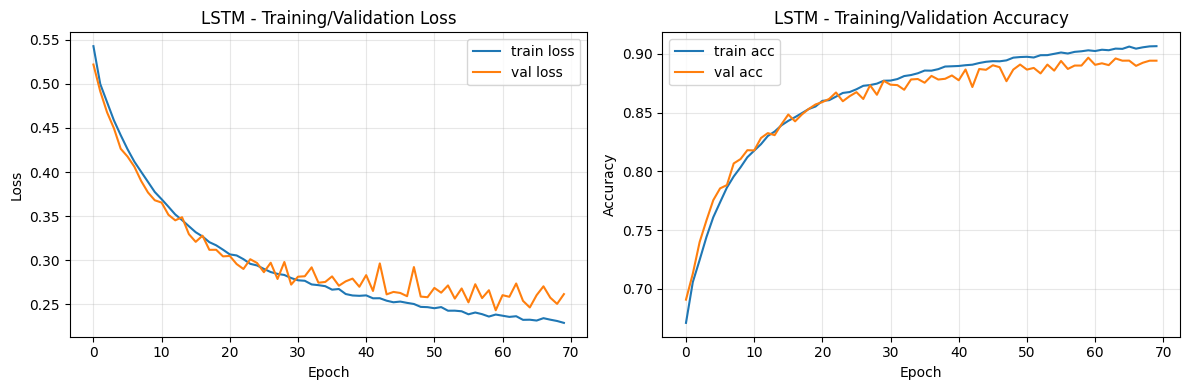

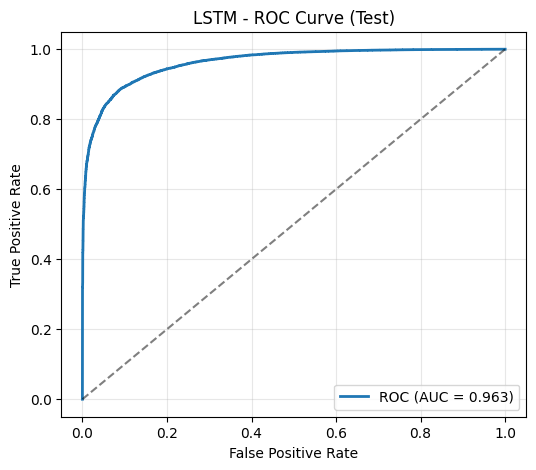


Per-Attack Performance:


,attack_type,num_seqs,acc,precision,recall,f1
0,AddObjectAttack,5922,0.984971,1.0,0.984971,0.992429
2,RemoveObjectAttack,5645,0.962622,1.0,0.962622,0.980955
3,WhiteNoiseAttack,6042,0.845912,1.0,0.845912,0.916525
1,DriftAttack,5697,0.771985,1.0,0.771985,0.871322



Benign sequences accuracy: 0.916

Training GRU

GRU Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,945 (136.50 KB)

 Trainable params: 34,945 (136.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6501 - loss: 0.5845 - val_accuracy: 0.6934 - val_loss: 0.5181
Epoch 2/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6929 - loss: 0.5297 - val_accuracy: 0.7045 - val_loss: 0.5042
Epoch 3/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7046 - loss: 0.5167 - val_accuracy: 0.7200 - val_loss: 0.4855
Epoch 4/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7172 - loss: 0.5043 - val_accuracy: 0.7253 - val_loss: 0.4844
Epoch 5/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7302 - loss: 0.4907 - val_accuracy: 0.7490 - val_loss: 0.4619
Epoch 6/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7408 - loss: 0.4809 - val_accuracy: 0.7562 - val_loss: 0.4546
Epoch 7/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7471 - loss: 0.4739 - val_accuracy: 0.7672 - val_loss: 0.4385
Epoch 8/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7543 - loss: 0

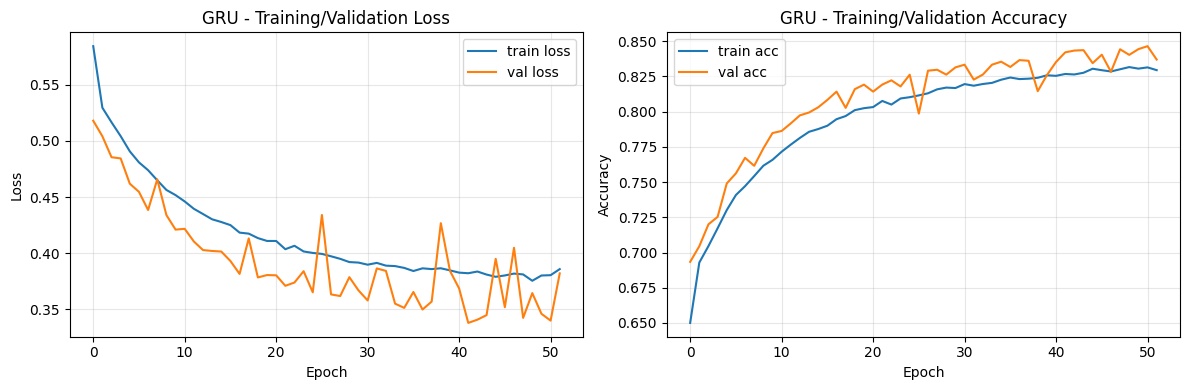

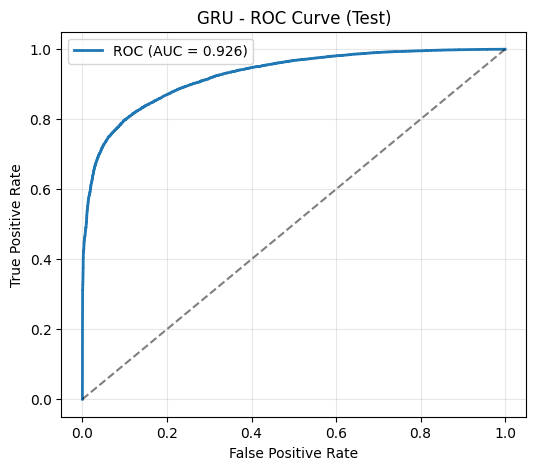


Per-Attack Performance:


,attack_type,num_seqs,acc,precision,recall,f1
0,AddObjectAttack,5922,0.986153,1.0,0.986153,0.993028
2,RemoveObjectAttack,5645,0.962976,1.0,0.962976,0.981139
3,WhiteNoiseAttack,6042,0.740152,1.0,0.740152,0.850675
1,DriftAttack,5697,0.667895,1.0,0.667895,0.800884



Benign sequences accuracy: 0.873

Training BiLSTM

BiLSTM Architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        87,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,201 (356.25 KB)

 Trainable params: 91,201 (356.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 69s 53ms/step - accuracy: 0.6728 - loss: 0.5423 - val_accuracy: 0.6928 - val_loss: 0.5093
Epoch 2/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 68s 53ms/step - accuracy: 0.7047 - loss: 0.4967 - val_accuracy: 0.7178 - val_loss: 0.4815
Epoch 3/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 68s 53ms/step - accuracy: 0.7252 - loss: 0.4760 - val_accuracy: 0.7292 - val_loss: 0.4796
Epoch 4/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.7406 - loss: 0.4565 - val_accuracy: 0.7573 - val_loss: 0.4434
Epoch 5/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 69s 54ms/step - accuracy: 0.7551 - loss: 0.4396 - val_accuracy: 0.7547 - val_loss: 0.4360
Epoch 6/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 218s 171ms/step - accuracy: 0.7669 - loss: 0.4227 - val_accuracy: 0.7724 - val_loss: 0.4184
Epoch 7/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 69s 54ms/step - accuracy: 0.7749 - loss: 0.4100 - val_accuracy: 0.7765 - val_loss: 0.4138
Epoch 8/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 69s 54ms/step - accuracy: 0.7832

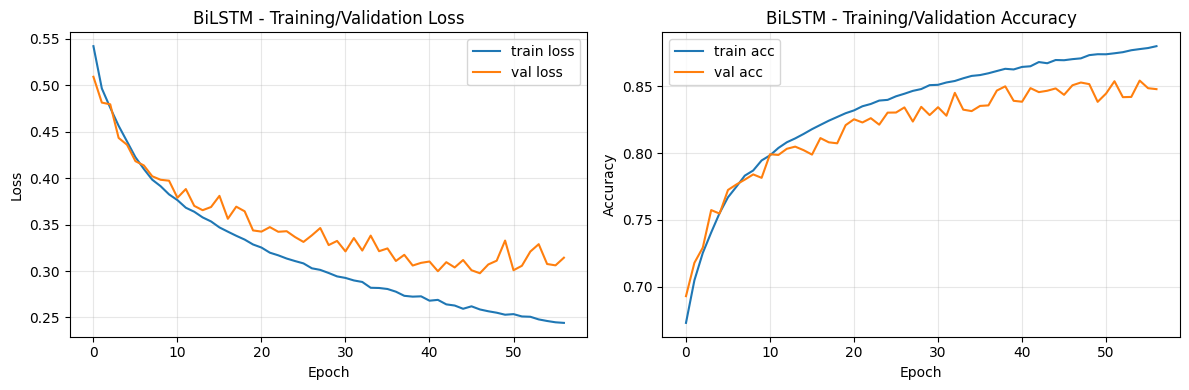

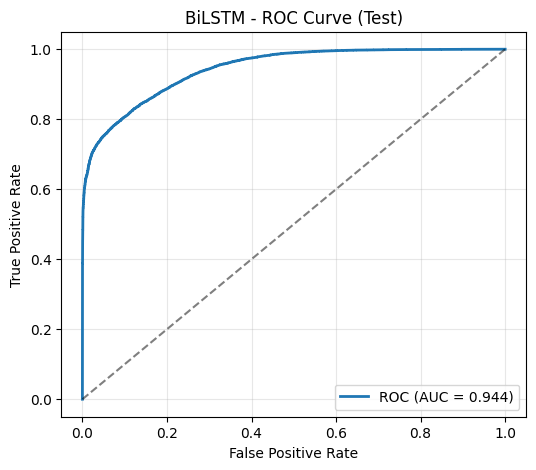


Per-Attack Performance:


,attack_type,num_seqs,acc,precision,recall,f1
0,AddObjectAttack,5922,0.987335,1.0,0.987335,0.993627
2,RemoveObjectAttack,5645,0.973959,1.0,0.973959,0.986808
3,WhiteNoiseAttack,6042,0.779874,1.0,0.779874,0.876325
1,DriftAttack,5697,0.707390,1.0,0.707390,0.828621



Benign sequences accuracy: 0.847

Training CNN-LSTM

CNN-LSTM Architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,361 (216.25 KB)

 Trainable params: 55,361 (216.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6639 - loss: 0.5503 - val_accuracy: 0.6728 - val_loss: 0.5192
Epoch 2/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6818 - loss: 0.5140 - val_accuracy: 0.6808 - val_loss: 0.5113
Epoch 3/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6902 - loss: 0.5041 - val_accuracy: 0.7020 - val_loss: 0.4918
Epoch 4/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6950 - loss: 0.5004 - val_accuracy: 0.7082 - val_loss: 0.4887
Epoch 5/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7012 - loss: 0.4966 - val_accuracy: 0.7056 - val_loss: 0.4915
Epoch 6/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7052 - loss: 0.4931 - val_accuracy: 0.7200 - val_loss: 0.4813
Epoch 7/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7092 - loss: 0.4899 - val_accuracy: 0.7253 - val_loss: 0.4728
Epoch 8/70
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7144 -

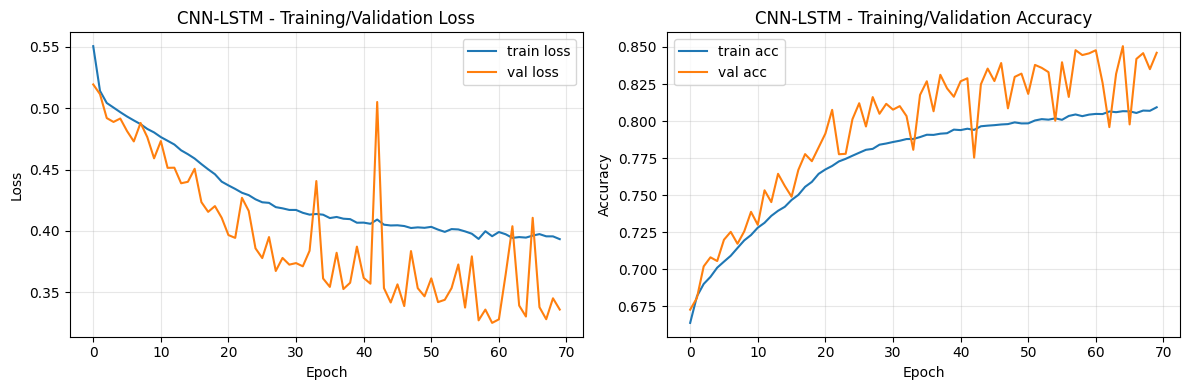

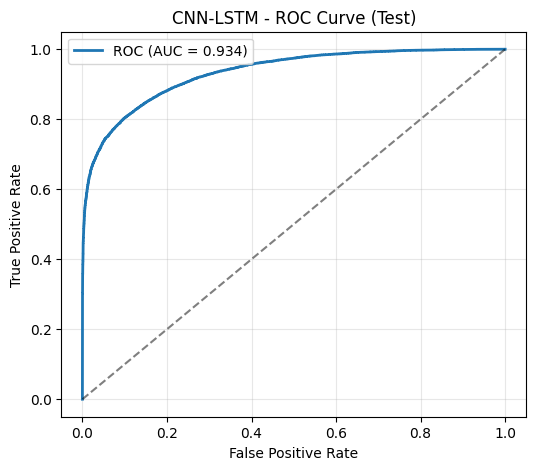


Per-Attack Performance:


,attack_type,num_seqs,acc,precision,recall,f1
0,AddObjectAttack,5922,0.988011,1.0,0.988011,0.993969
2,RemoveObjectAttack,5645,0.960850,1.0,0.960850,0.980034
3,WhiteNoiseAttack,6042,0.762827,1.0,0.762827,0.865459
1,DriftAttack,5697,0.692294,1.0,0.692294,0.818172



Benign sequences accuracy: 0.869

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Benign Acc
0,LSTM,0.8960,0.9325,0.8956,0.9136,0.9628,0.9161
1,GRU,0.8434,0.8988,0.8398,0.8683,0.9262,0.8735
2,BiLSTM,0.8515,0.8924,0.8624,0.8771,0.9436,0.8468
3,CNN-LSTM,0.8493,0.8974,0.8522,0.8742,0.9336,0.8690


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Benign Acc
0,LSTM,0.895958,0.932485,0.895556,0.913648,0.962803,0.916065
1,GRU,0.843422,0.898811,0.839779,0.868293,0.926203,0.873455
2,BiLSTM,0.851478,0.892357,0.862369,0.877107,0.943626,0.846814
3,CNN-LSTM,0.849307,0.897450,0.852189,0.874234,0.933636,0.868962


In [63]:
# 1. Define which models to train
model_configs = {
    'LSTM': build_lstm,
    'GRU': build_gru,
    'BiLSTM': build_bilstm,
    'CNN-LSTM': build_cnn_lstm,
}

# 2. Train all models at once
results = train_and_evaluate_models(
    X=X,
    y=y,
    df_seq_meta=df_seq_meta,
    model_configs=model_configs,
    epochs=70,
    batch_size=128,
    patience=10
)

# 3. View comparison
results['comparison_table']

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


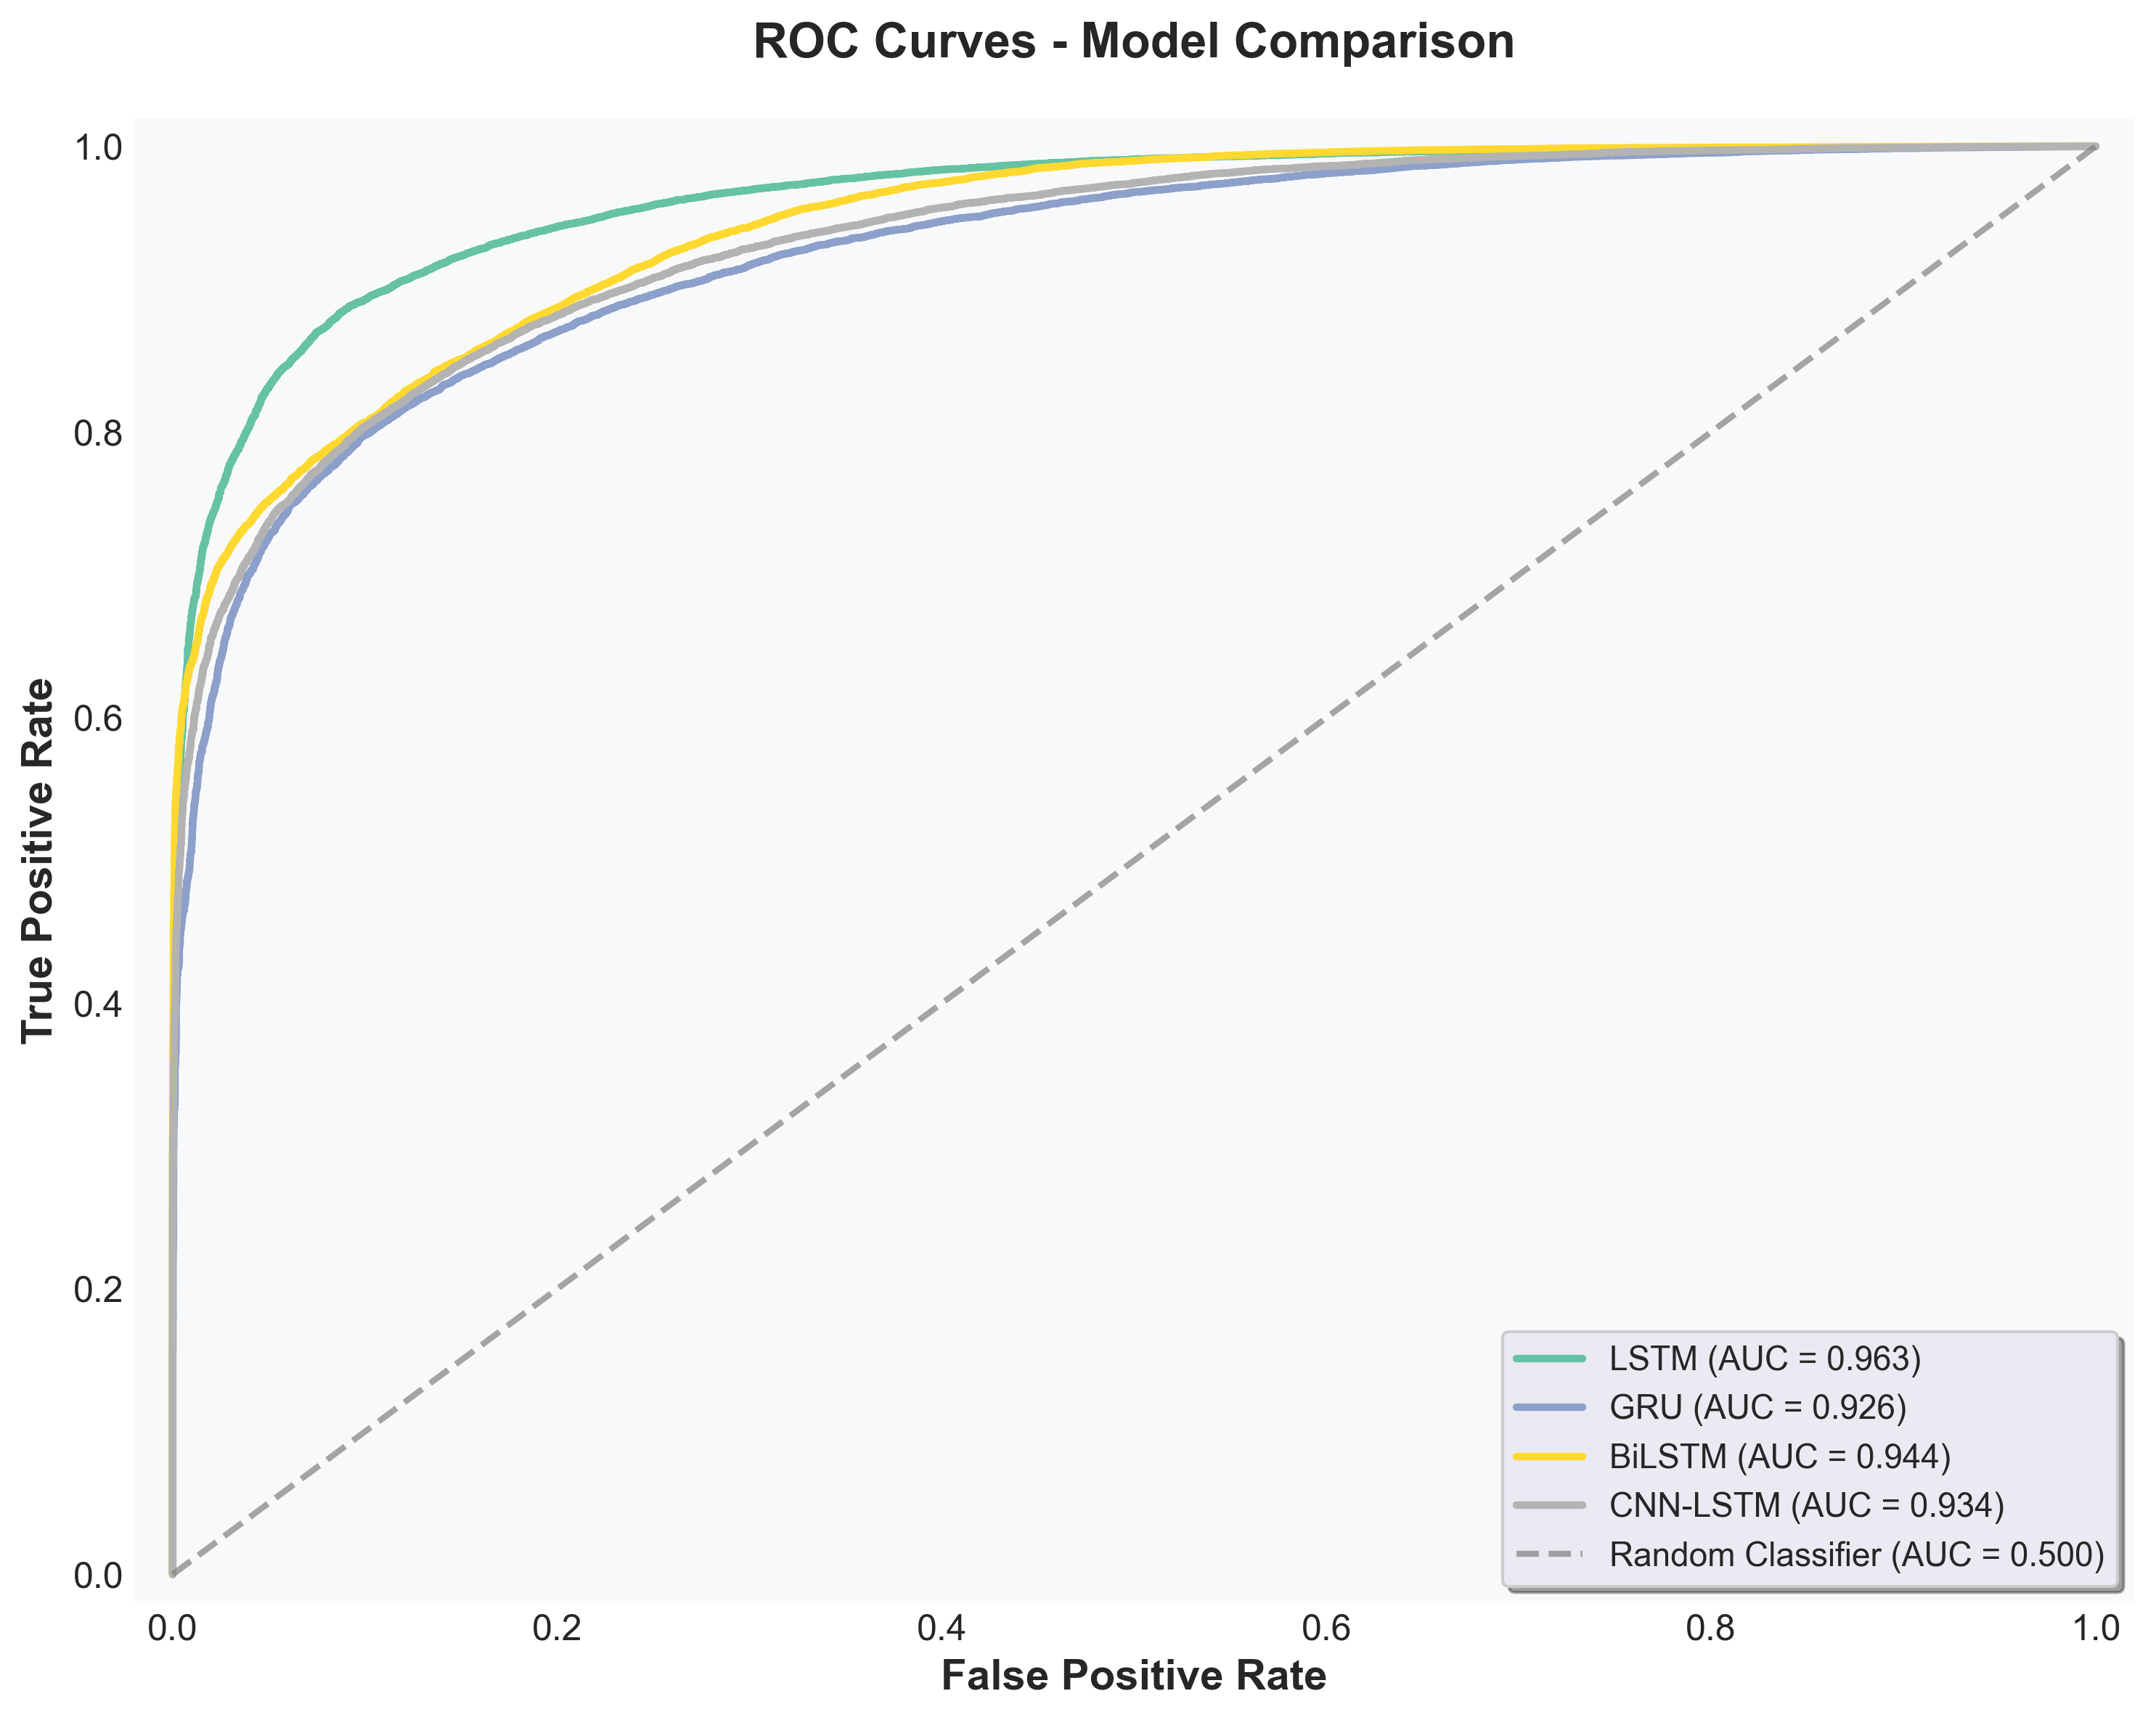

In [64]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Recreate the test set the same way your training function does
data_dict = prepare_data(X, y, df_seq_meta)
X_test = data_dict["X_test"]
y_test = data_dict["y_test"]

# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# Color palette for multiple models
colors = plt.cm.Set2(np.linspace(0, 1, len([k for k in results.keys() if k != "comparison_table"])))

for idx, (name, r) in enumerate(results.items()):
    if name == "comparison_table":
        continue
    
    model = r["model"]
    probs = model.predict(X_test, batch_size=256).ravel()  # P(malicious)
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, 
            label=f"{name} (AUC = {roc_auc:.3f})", 
            linewidth=2.5,
            color=colors[idx])

# Plot diagonal reference line
ax.plot([0, 1], [0, 1], 
        linestyle="--", 
        color="gray", 
        linewidth=2, 
        alpha=0.7,
        label="Random Classifier (AUC = 0.500)")

# Styling
ax.set_xlabel("False Positive Rate", fontsize=14, fontweight='bold')
ax.set_ylabel("True Positive Rate", fontsize=14, fontweight='bold')
ax.set_title("ROC Curves - Model Comparison", fontsize=16, fontweight='bold', pad=20)

# Grid and legend
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc="lower right", fontsize=11, frameon=True, shadow=True, fancybox=True)

# Axis limits and ticks
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.tick_params(axis='both', which='major', labelsize=12)

# Add a subtle background
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig("ROC_curves_professional.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [65]:
from pathlib import Path

models_path = Path("models")
models_path.mkdir(parents=True, exist_ok=True)

for idx, (name, r) in enumerate(results.items()):
    if name == "comparison_table":
        continue

    model_name = name + ".keras"
    model_path = models_path / model_name
    
    model = r["model"]
    model.save(model_path)

In [ ]:
# Optional extra visualization
if "visualize_attack_distribution" in globals():
    freq_df, complexity = visualize_attack_distribution(
        df=df_veh,
        attack_col='cpm_attack_types',
        malicious_col='cpm_is_malicious',
        figsize=(16, 12)
    )
else:
    print("visualize_attack_distribution(...) is not defined in this notebook. Skipping optional plot.")

